Подгружаем датасет

In [42]:
import pandas as pd

train = pd.read_csv("/content/rusentitweet_train.csv")
test = pd.read_csv("/content/rusentitweet_test.csv")

print("TRAIN shape:", train.shape)
print("TEST shape:", test.shape)

print("\nTRAIN columns:")
print(train.columns.tolist())

print("\nTEST columns:")
print(test.columns.tolist())

print("\nTRAIN head:")
display(train.head())

print("\nTEST head:")
display(test.head())

TRAIN shape: (10713, 3)
TEST shape: (2679, 3)

TRAIN columns:
['text', 'label', 'id']

TEST columns:
['text', 'label', 'id']

TRAIN head:


,text,label,id
0,Помойму я вкрашилась в Чимина🤧 https://t.co/t2...,positive,1282311169534038016
1,@namaskaramsaroo Мотоцикль,neutral,1272864221202530309
2,Михаил Мишустин: меры по борьбе с коронавирусо...,neutral,1296860899739947008
3,@bbsbro_ доброй ноченьки 💕,speech,1288168112425246721
4,ну что пойду чекну фоточки,neutral,1287678712612364288



TEST head:


,text,label,id
0,все мы помним мой ахуй https://t.co/3Kr7yzeYLC,skip,1318021368932421633
1,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
2,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
3,бэк дор соти https://t.co/bYCWz4h4Sk,skip,1306944400824709120
4,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209


In [ ]:
print("TRAIN labels:")
print(train["label"].value_counts())
print()

print("TEST labels:")
print(test["label"].value_counts())


TRAIN labels:
label
neutral     4273
negative    2638
positive    1931
skip        1474
speech       397
Name: count, dtype: int64

TEST labels:
label
neutral     1068
negative     660
positive     483
skip         369
speech        99
Name: count, dtype: int64


Оставляем только 3 нужных класса



In [ ]:
allowed_labels = ["positive", "neutral", "negative"]

train_3 = train[train["label"].isin(allowed_labels)].copy()
test_3 = test[test["label"].isin(allowed_labels)].copy()

print("TRAIN_3 shape:", train_3.shape)
print("TEST_3 shape:", test_3.shape)
print()

print("TRAIN_3 labels:")
print(train_3["label"].value_counts())
print()

print("TEST_3 labels:")
print(test_3["label"].value_counts())

TRAIN_3 shape: (8842, 3)
TEST_3 shape: (2211, 3)

TRAIN_3 labels:
label
neutral     4273
negative    2638
positive    1931
Name: count, dtype: int64

TEST_3 labels:
label
neutral     1068
negative     660
positive     483
Name: count, dtype: int64


Проверяем пустые значения и дубликаты

In [ ]:
print("Пустые тексты в train_3:", train_3["text"].isna().sum())
print("Пустые тексты в test_3:", test_3["text"].isna().sum())

train_3 = train_3.drop_duplicates(subset=["text"])
test_3 = test_3.drop_duplicates(subset=["text"])

print("TRAIN_3 after duplicates:", train_3.shape)
print("TEST_3 after duplicates:", test_3.shape)

Пустые тексты в train_3: 0
Пустые тексты в test_3: 0
TRAIN_3 after duplicates: (8842, 3)
TEST_3 after duplicates: (2211, 3)


Оставляем только нужные значения

In [ ]:
train_3 = train_3[["text", "label"]].copy()
test_3 = test_3[["text", "label"]].copy()

display(train_3.head())
display(test_3.head())

,text,label
0,Помойму я вкрашилась в Чимина🤧 https://t.co/t2...,positive
1,@namaskaramsaroo Мотоцикль,neutral
2,Михаил Мишустин: меры по борьбе с коронавирусо...,neutral
4,ну что пойду чекну фоточки,neutral
5,@buybread_ я не с порядке!!!!,negative


,text,label
1,я считаю это мем года https://t.co/xoVKj5y8Mj,positive
2,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive
4,@daria_karapet * терияки бойз начинает играть*,neutral
5,(пушка на Караульной горе больше не стреляет Б...,negative
6,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive


Сохраням очищенные данные

In [ ]:
train_3.to_csv("rusentitweet_train_3class.csv", index=False)
test_3.to_csv("rusentitweet_test_3class.csv", index=False)

Подготовим X и Y

In [ ]:
X_train = train_3["text"]
y_train = train_3["label"]

X_test = test_3["text"]
y_test = test_3["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8842,)
y_train: (8842,)
X_test: (2211,)
y_test: (2211,)


Построим TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (8842, 8917)
X_test_tfidf shape: (2211, 8917)


Обучим первую модель -- baseline

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_tfidf, y_train)

y_pred_dummy = dummy.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred_dummy)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_dummy, average="weighted", zero_division=0
)

print("DummyClassifier results:")
print("Accuracy:", round(acc, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

DummyClassifier results:
Accuracy: 0.483
Precision: 0.2333
Recall: 0.483
F1-score: 0.3147


Функция для оценки модели

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    }

Обучаем LR

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg_result = evaluate_model(
    log_reg,
    X_train_tfidf, y_train,
    X_test_tfidf, y_test,
    "Logistic Regression"
)

print(log_reg_result)

{'Model': 'Logistic Regression', 'Accuracy': 0.6106, 'Precision': 0.6207, 'Recall': 0.6106, 'F1-score': 0.5921}


Обучаем SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_result = evaluate_model(
    svm_model,
    X_train_tfidf, y_train,
    X_test_tfidf, y_test,
    "Linear SVM"
)

print(svm_result)

{'Model': 'Linear SVM', 'Accuracy': 0.6061, 'Precision': 0.6015, 'Recall': 0.6061, 'F1-score': 0.5975}


Multinomial Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_result = evaluate_model(
    nb_model,
    X_train_tfidf, y_train,
    X_test_tfidf, y_test,
    "Multinomial Naive Bayes"
)

print(nb_result)

{'Model': 'Multinomial Naive Bayes', 'Accuracy': 0.5957, 'Precision': 0.65, 'Recall': 0.5957, 'F1-score': 0.5521}


Итоговая таблица

In [ ]:
import pandas as pd

dummy_result = {
    "Model": "DummyClassifier",
    "Accuracy": round(acc, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4)
}

results_df = pd.DataFrame([
    dummy_result,
    log_reg_result,
    svm_result,
    nb_result
])

results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM,0.6061,0.6015,0.6061,0.5975
1,Logistic Regression,0.6106,0.6207,0.6106,0.5921
2,Multinomial Naive Bayes,0.5957,0.6500,0.5957,0.5521
3,DummyClassifier,0.4830,0.2333,0.4830,0.3147


Сохраняем ее

In [ ]:
results_df.to_csv("model_results.csv", index=False)

Построим график сравнения моделей

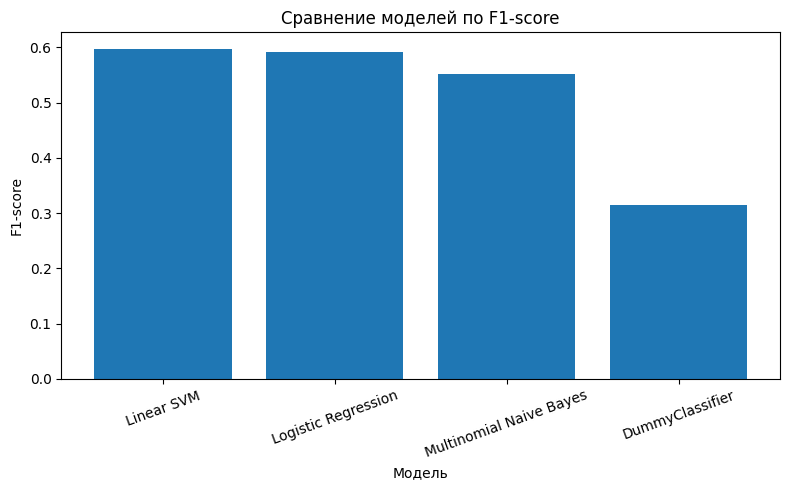

In [ ]:
import matplotlib.pyplot as plt

results_plot = results_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(results_plot["Model"], results_plot["F1-score"])
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Определяем лучшую модель и получаем результаты предсказания

In [ ]:
best_model = LinearSVC(random_state=42)
best_model.fit(X_train_tfidf, y_train)

y_pred_best = best_model.predict(X_test_tfidf)

Строим confusion matrix

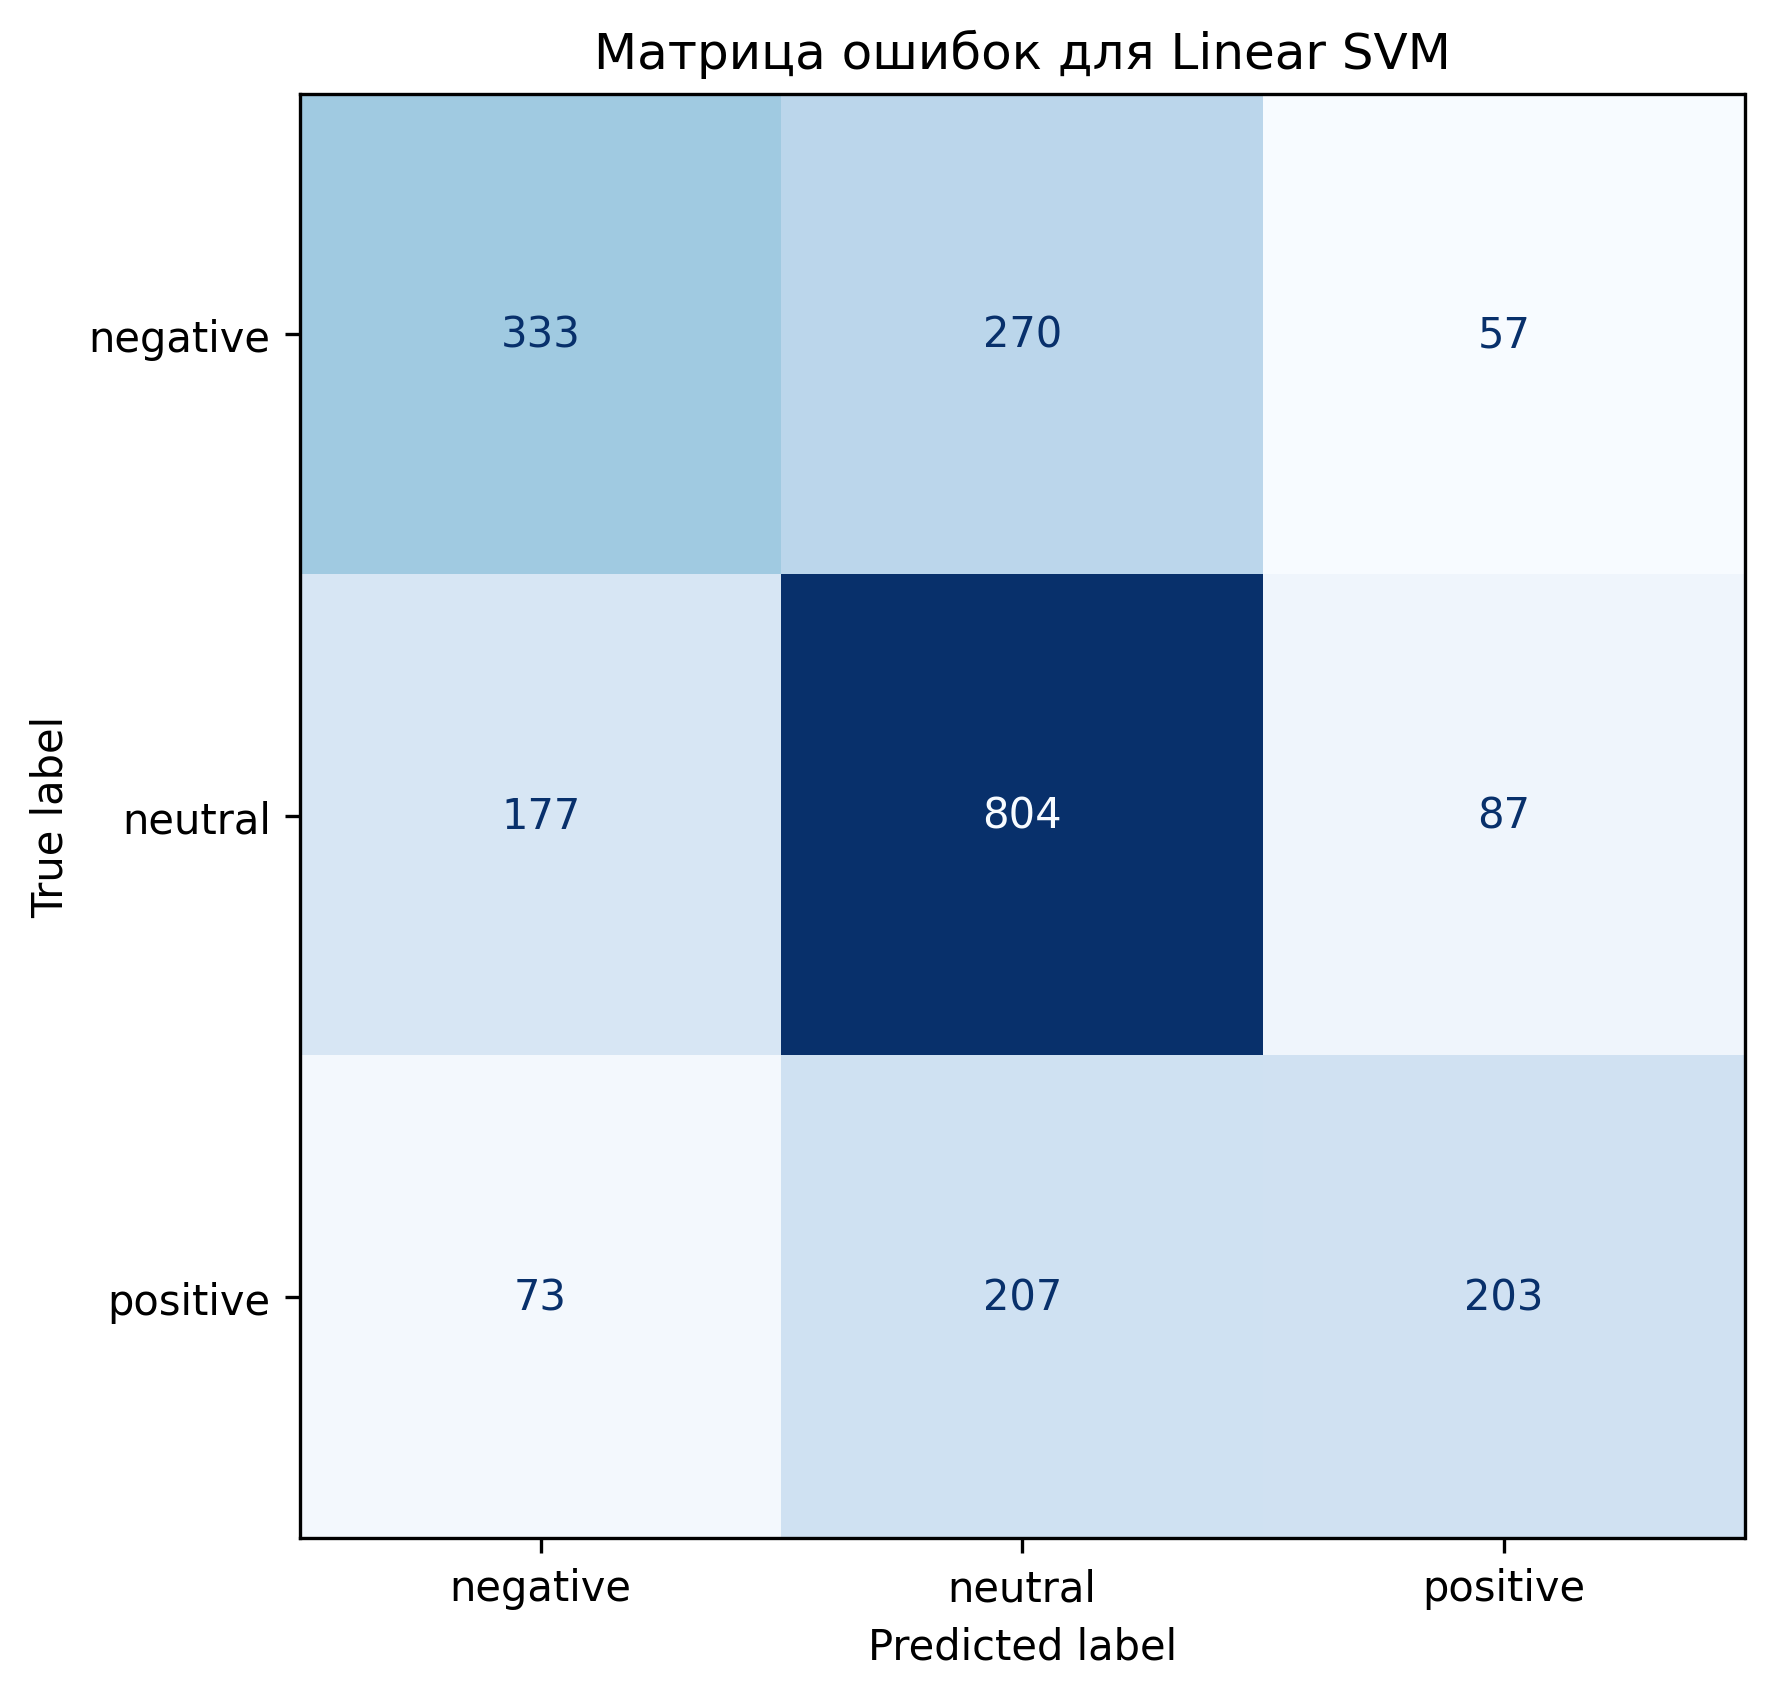

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_order = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, y_pred_best, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для Linear SVM")
plt.tight_layout()
plt.show()

Подробный отчет

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best, digits=4))

              precision    recall  f1-score   support

    negative     0.5712    0.5045    0.5358       660
     neutral     0.6276    0.7528    0.6845      1068
    positive     0.5850    0.4203    0.4892       483

    accuracy                         0.6061      2211
   macro avg     0.5946    0.5592    0.5698      2211
weighted avg     0.6015    0.6061    0.5975      2211



Сохраняем графики

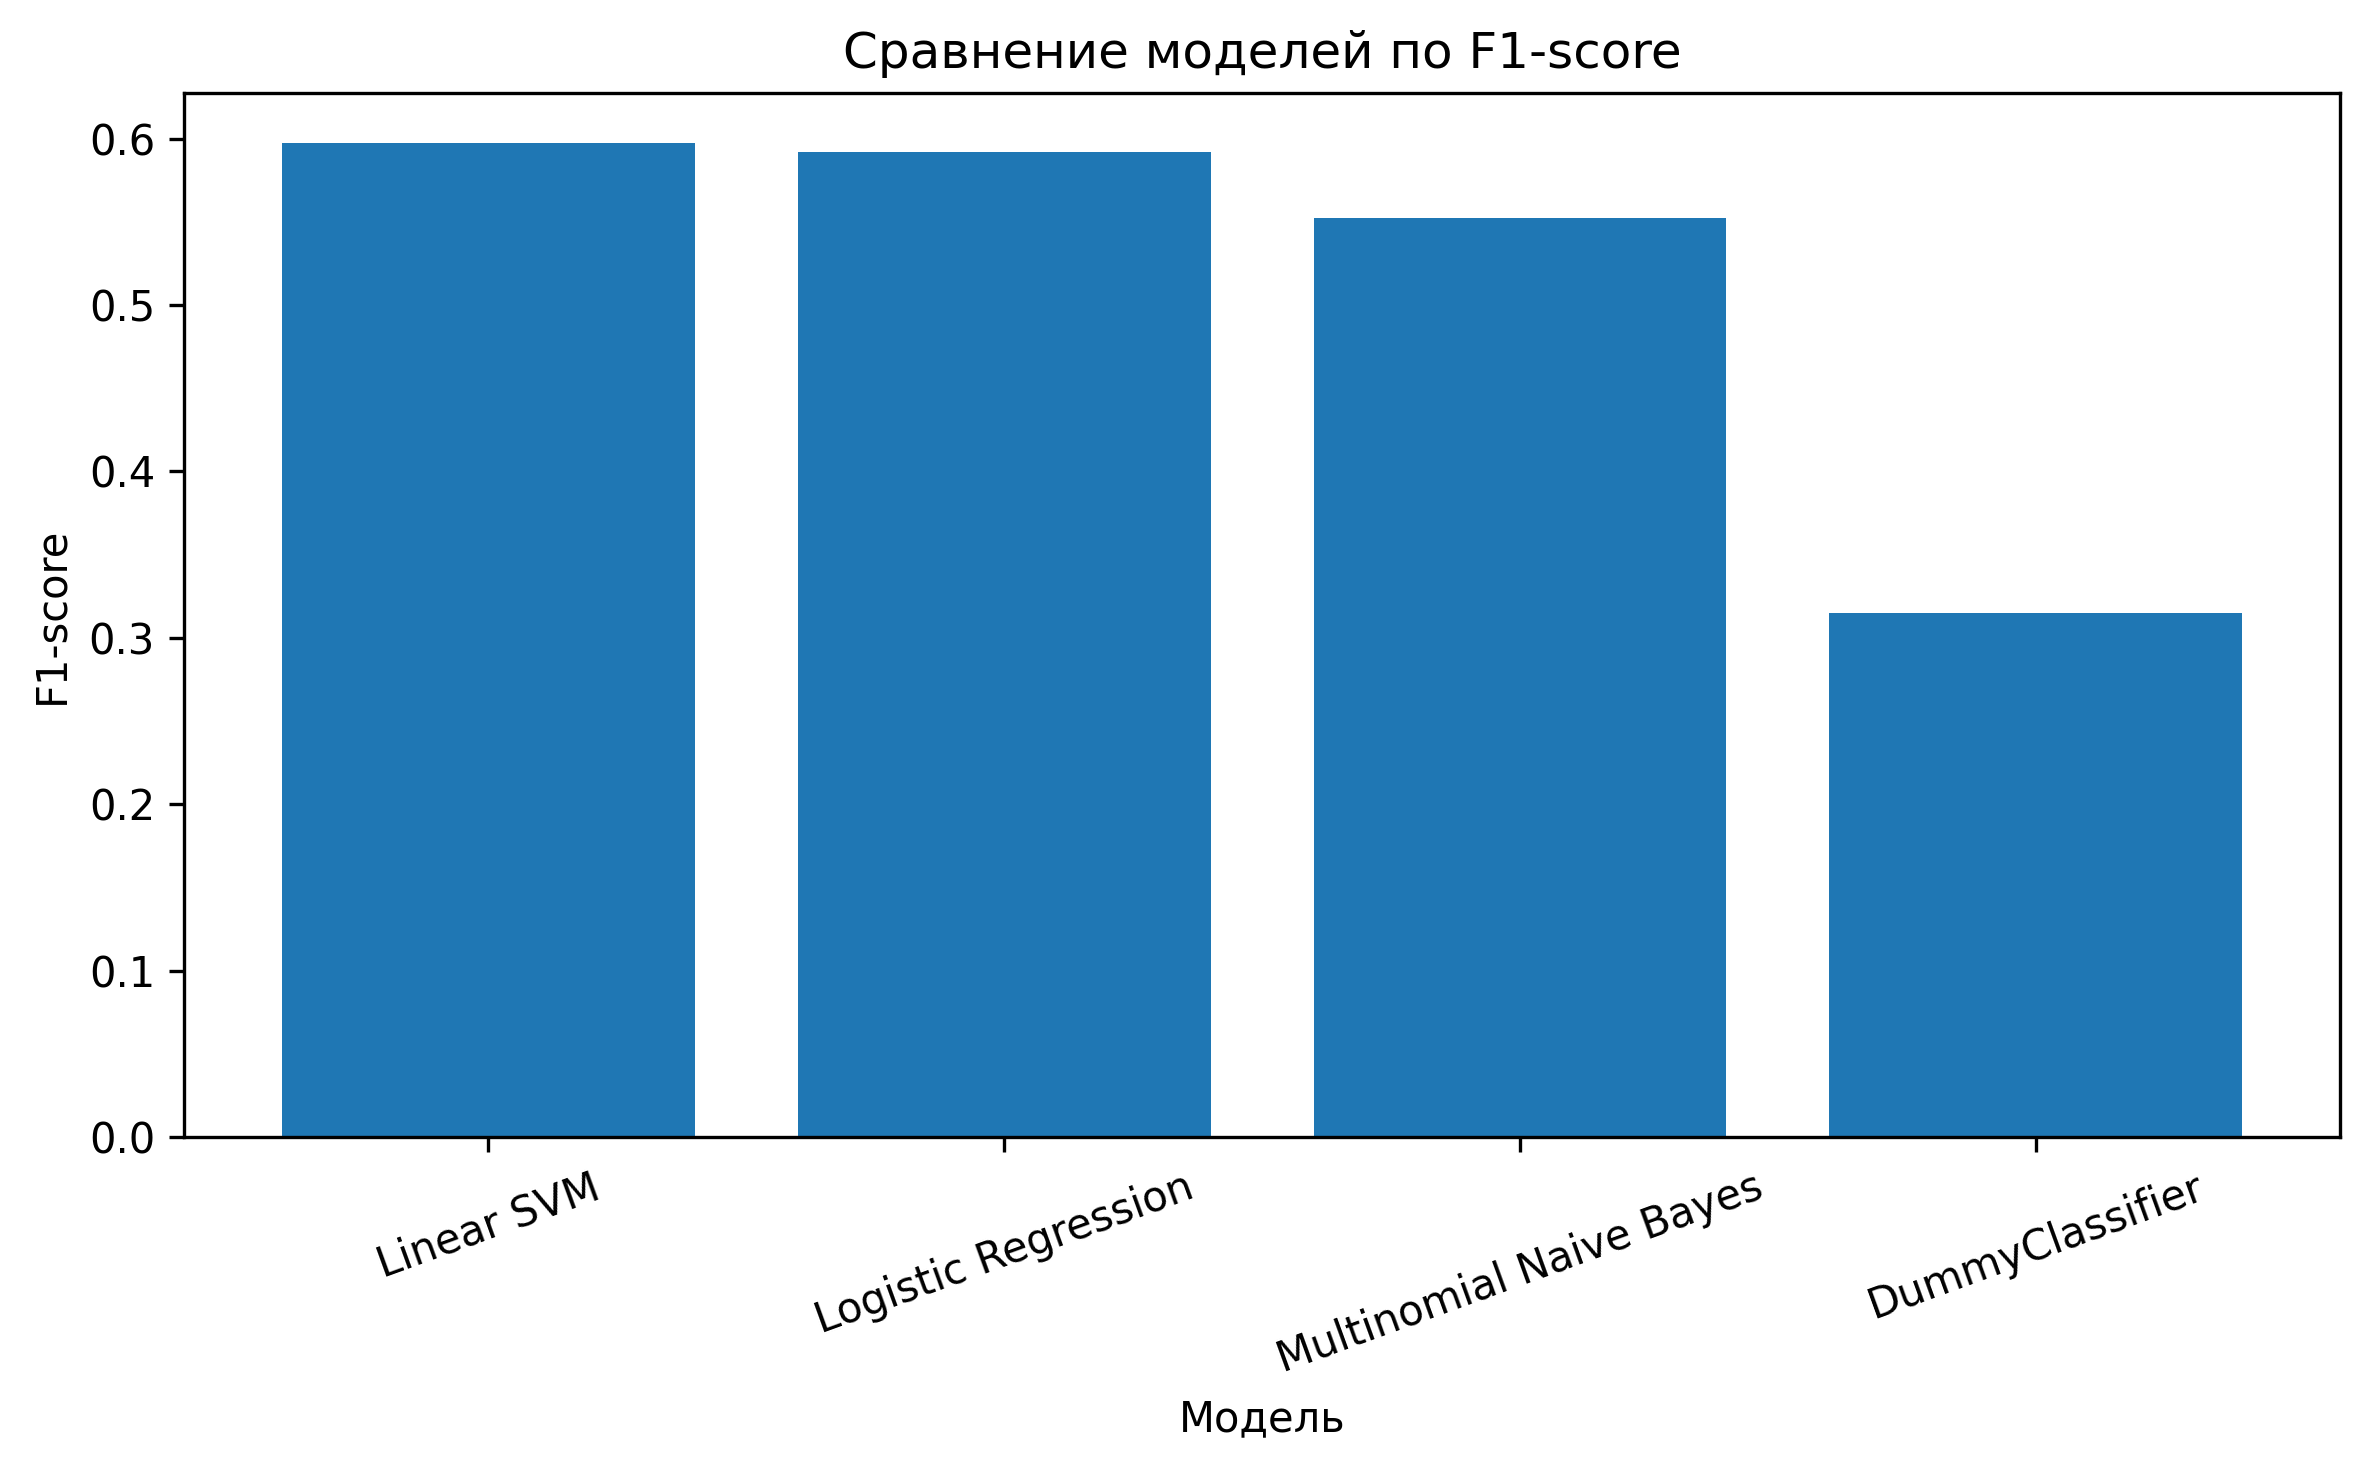

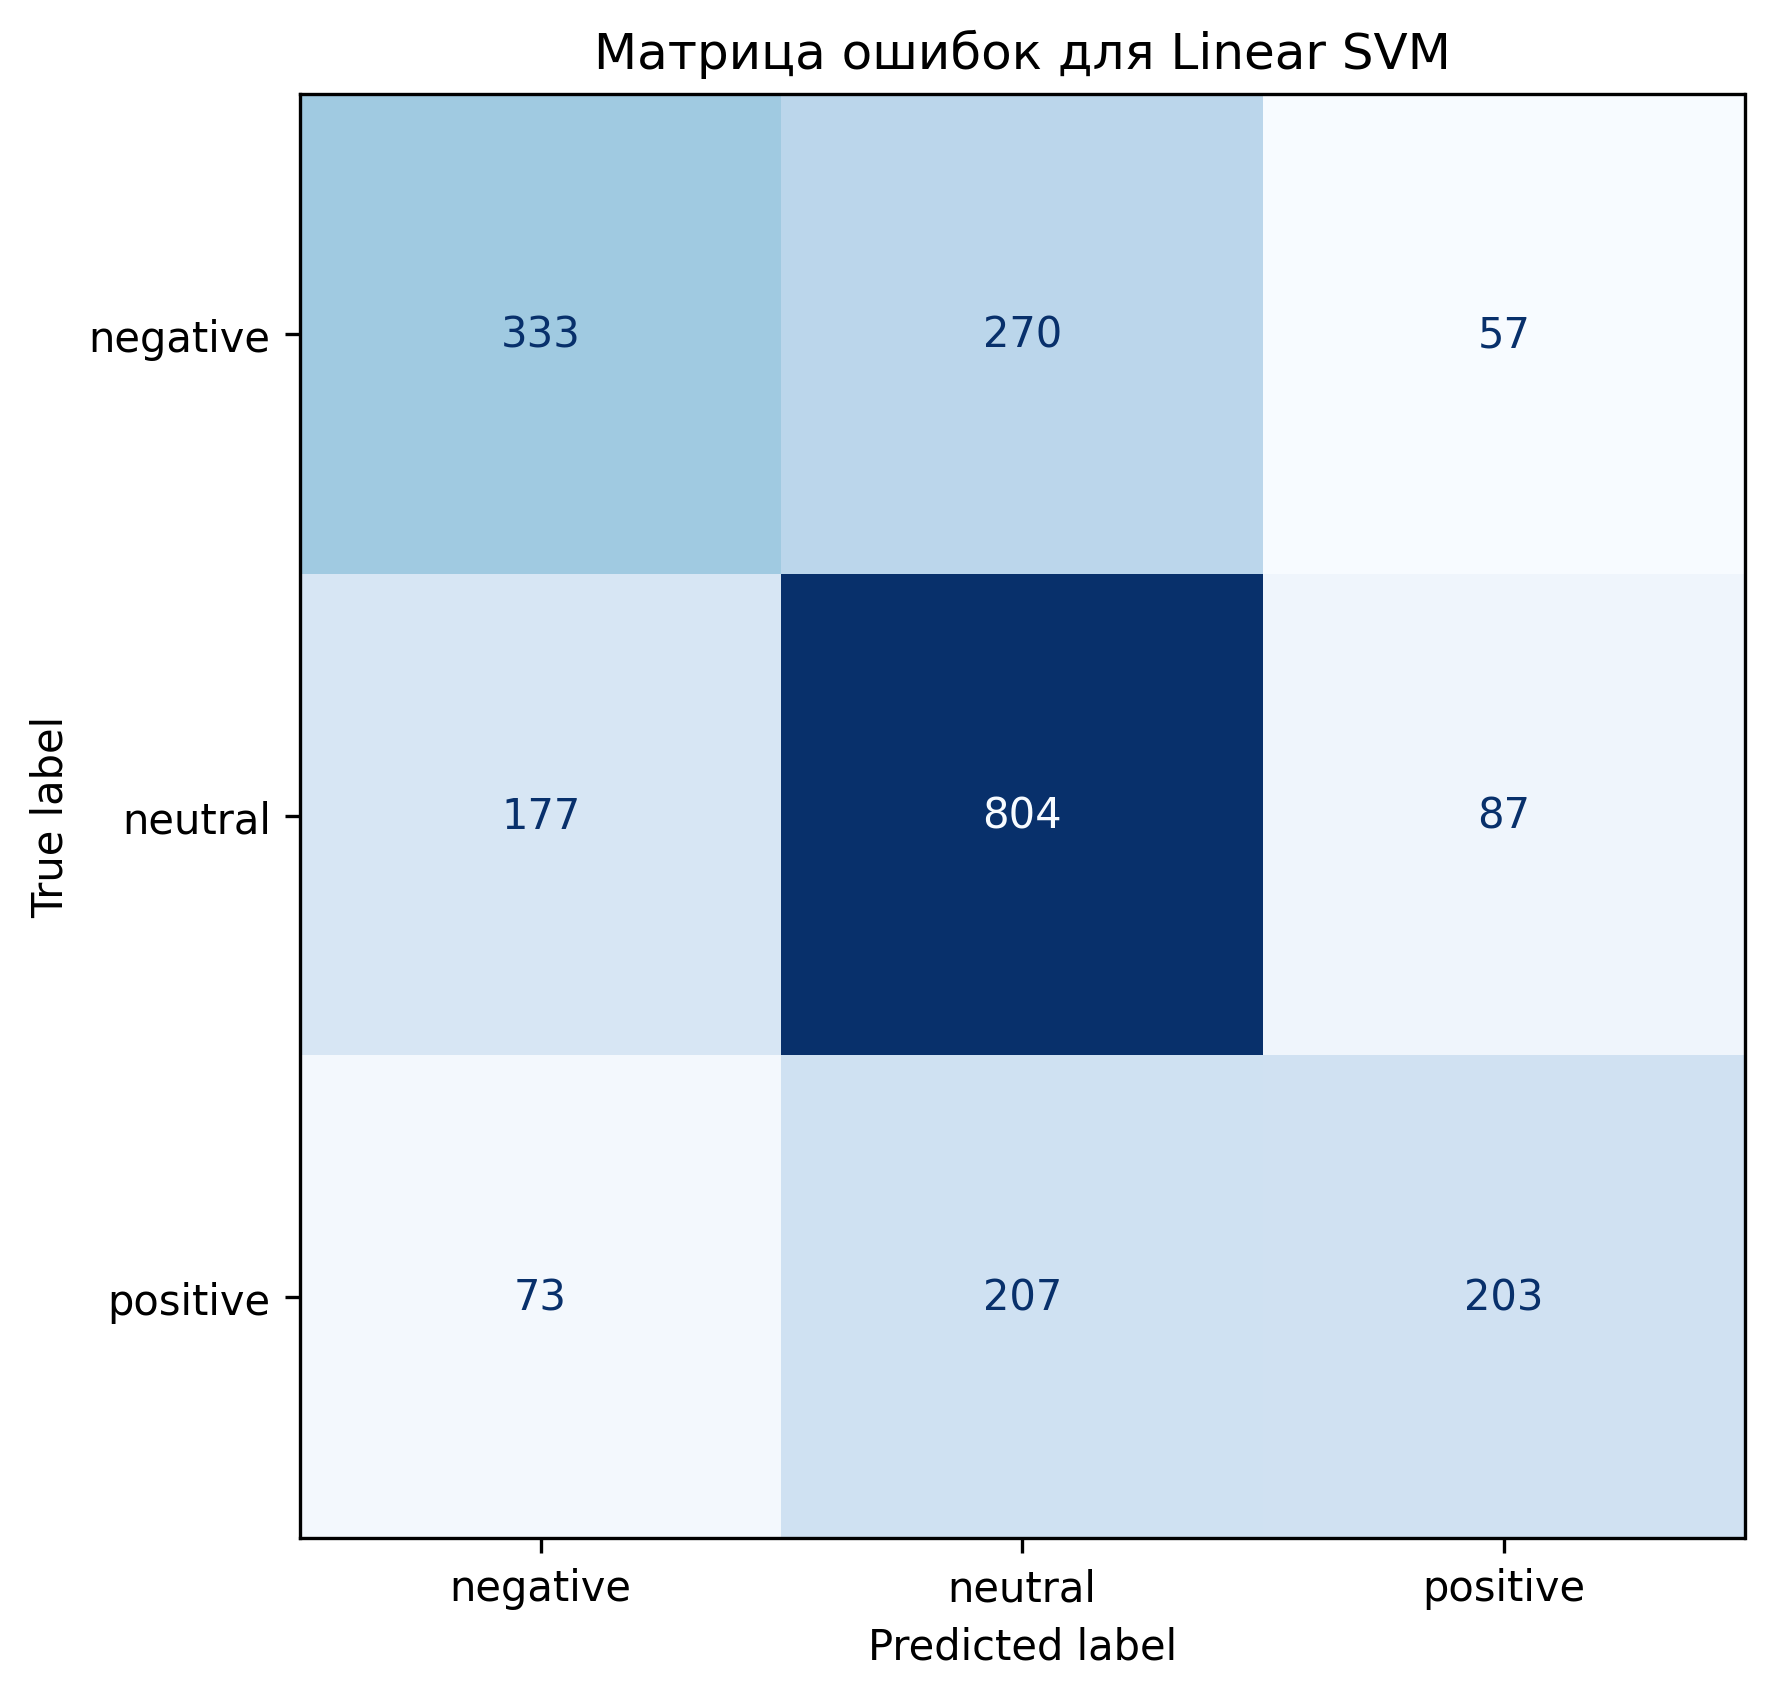

In [ ]:
# График сравнения моделей
results_plot = results_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(results_plot["Model"], results_plot["F1-score"])
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=300)
plt.show()

# Матрица ошибок
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для Linear SVM")
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=300)
plt.show()

Установка библиотек

In [ ]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


Проверка GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


Перекодируем метки в числа

In [ ]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {v: k for k, v in label2id.items()}

train_hf = train_3.copy()
test_hf = test_3.copy()

train_hf["label_id"] = train_hf["label"].map(label2id)
test_hf["label_id"] = test_hf["label"].map(label2id)

display(train_hf.head())
display(test_hf.head())

,text,label,label_id
0,Помойму я вкрашилась в Чимина🤧 https://t.co/t2...,positive,2
1,@namaskaramsaroo Мотоцикль,neutral,1
2,Михаил Мишустин: меры по борьбе с коронавирусо...,neutral,1
4,ну что пойду чекну фоточки,neutral,1
5,@buybread_ я не с порядке!!!!,negative,0


,text,label,label_id
1,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,2
2,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,2
4,@daria_karapet * терияки бойз начинает играть*,neutral,1
5,(пушка на Караульной горе больше не стреляет Б...,negative,0
6,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,2


Делаем из pandas Hugging Face Dataset

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_hf[["text", "label_id"]])
test_dataset = Dataset.from_pandas(test_hf[["text", "label_id"]])

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 8842
})
Dataset({
    features: ['text', 'label_id', '__index_level_0__'],
    num_rows: 2211
})


Задаем модель и токенизатор

In [ ]:
model_name = "cointegrated/rubert-tiny2"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Токенизация

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/8842 [00:00<?, ? examples/s]

Map:   0%|          | 0/2211 [00:00<?, ? examples/s]

Подготавливаем к Trainer

In [ ]:
train_tokenized = train_tokenized.rename_column("label_id", "labels")
test_tokenized = test_tokenized.rename_column("label_id", "labels")

train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Загружаем модель

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Подготовим метрики

In [ ]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    precision_w = precision_metric.compute(predictions=preds, references=labels, average="weighted")["precision"]
    recall_w = recall_metric.compute(predictions=preds, references=labels, average="weighted")["recall"]
    f1_w = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    f1_m = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]

    return {
        "accuracy": accuracy,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "f1_macro": f1_m
    }

Настраиваем обучение

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./rubert_tiny_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True
)

Создаем Trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

Обучаем

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.835154,0.760922,0.678426,0.679749,0.678426,0.673077,0.649783
2,0.720184,0.726659,0.691995,0.690055,0.691995,0.690045,0.672982


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=1106, training_loss=0.8199497713533922, metrics={'train_runtime': 43.1425, 'train_samples_per_second': 409.897, 'train_steps_per_second': 25.636, 'total_flos': 32605619991552.0, 'train_loss': 0.8199497713533922, 'epoch': 2.0})

Получаем итоговую оценку модели

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.72665935754776, 'eval_accuracy': 0.6919945725915875, 'eval_precision_weighted': 0.6900546995022533, 'eval_recall_weighted': 0.6919945725915875, 'eval_f1_weighted': 0.6900446430208242, 'eval_f1_macro': 0.6729815380801144, 'eval_runtime': 1.8152, 'eval_samples_per_second': 1218.06, 'eval_steps_per_second': 76.576, 'epoch': 2.0}


Получаем предсказания модели

In [ ]:
pred_output = trainer.predict(test_tokenized)

Достаем предсказанные классы и истинные метки

In [ ]:
import numpy as np

y_pred_bert = np.argmax(pred_output.predictions, axis=-1)
y_true_bert = pred_output.label_ids

print("Pred shape:", y_pred_bert.shape)
print("True shape:", y_true_bert.shape)

Pred shape: (2211,)
True shape: (2211,)


Строим подробный отчет о классификации

In [ ]:
from sklearn.metrics import classification_report

label_names = ["negative", "neutral", "positive"]

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_names,
    digits=4
))

              precision    recall  f1-score   support

    negative     0.6526    0.6318    0.6420       660
     neutral     0.7220    0.7734    0.7468      1068
    positive     0.6706    0.5942    0.6301       483

    accuracy                         0.6920      2211
   macro avg     0.6817    0.6665    0.6730      2211
weighted avg     0.6901    0.6920    0.6900      2211



Строим confusion matrix BERT

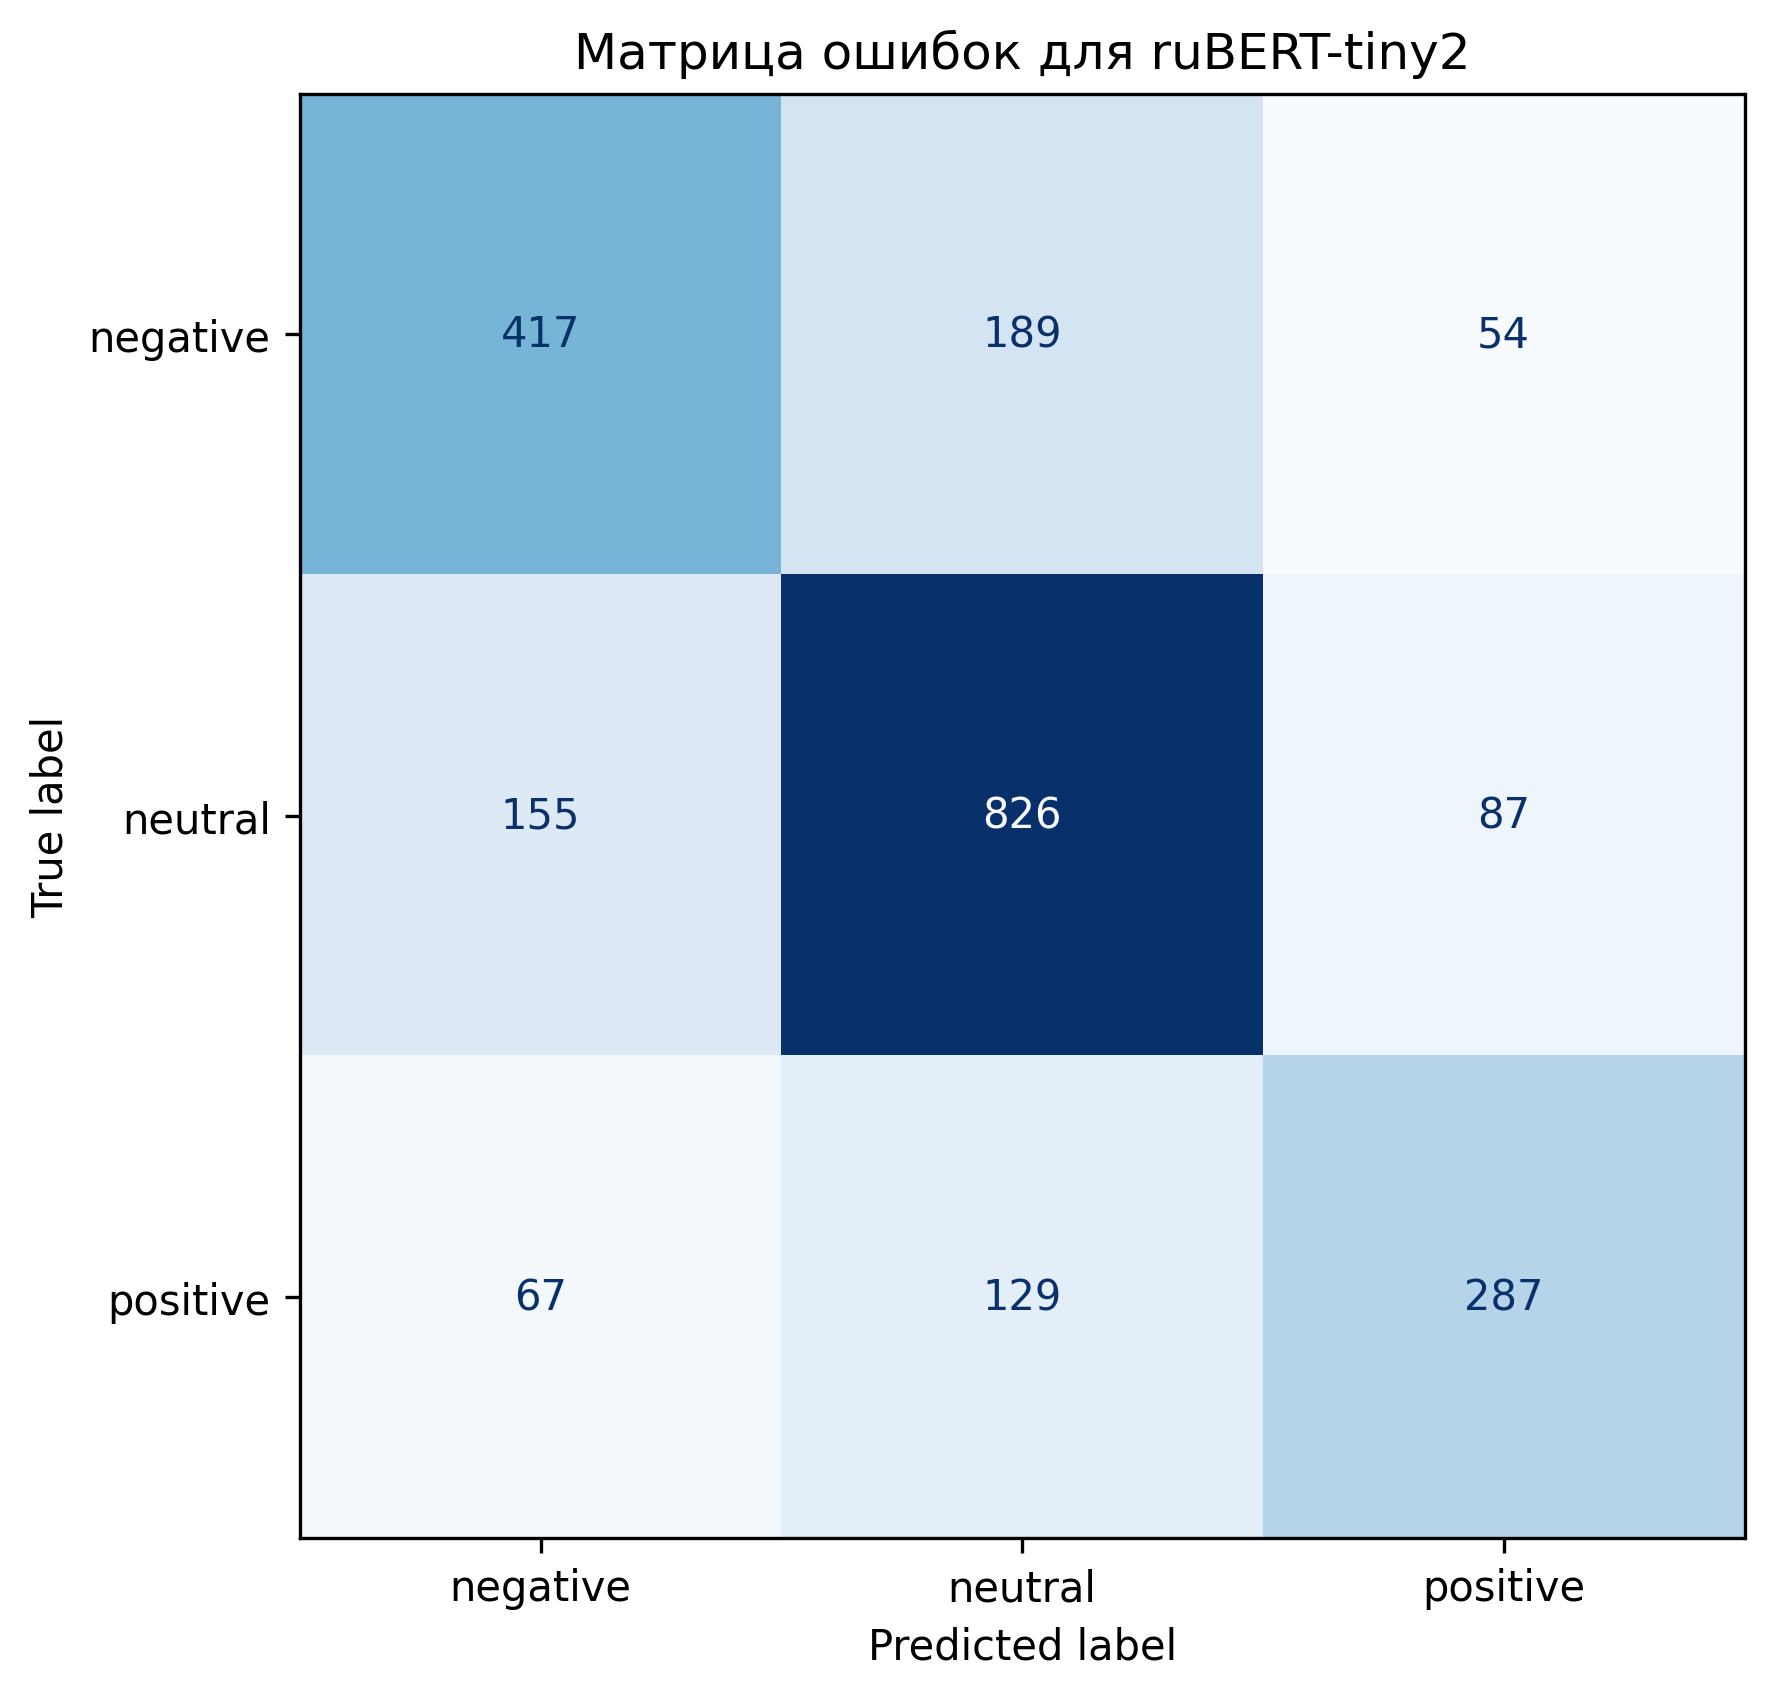

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bert = confusion_matrix(y_true_bert, y_pred_bert, labels=[0, 1, 2])
disp_bert = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для ruBERT-tiny2")
plt.tight_layout()
plt.show()

Добавим Bert в общую таблицу результатов

In [ ]:
bert_result = {
    "Model": "ruBERT-tiny2",
    "Accuracy": round(eval_results["eval_accuracy"], 4),
    "Precision": round(eval_results["eval_precision_weighted"], 4),
    "Recall": round(eval_results["eval_recall_weighted"], 4),
    "F1-score": round(eval_results["eval_f1_weighted"], 4)
}

results_df = pd.concat([results_df, pd.DataFrame([bert_result])], ignore_index=True)
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,ruBERT-tiny2,0.6920,0.6901,0.6920,0.6900
1,Linear SVM,0.6061,0.6015,0.6061,0.5975
2,Logistic Regression,0.6106,0.6207,0.6106,0.5921
3,Multinomial Naive Bayes,0.5957,0.6500,0.5957,0.5521
4,DummyClassifier,0.4830,0.2333,0.4830,0.3147


Обновленны график со всеми моделями

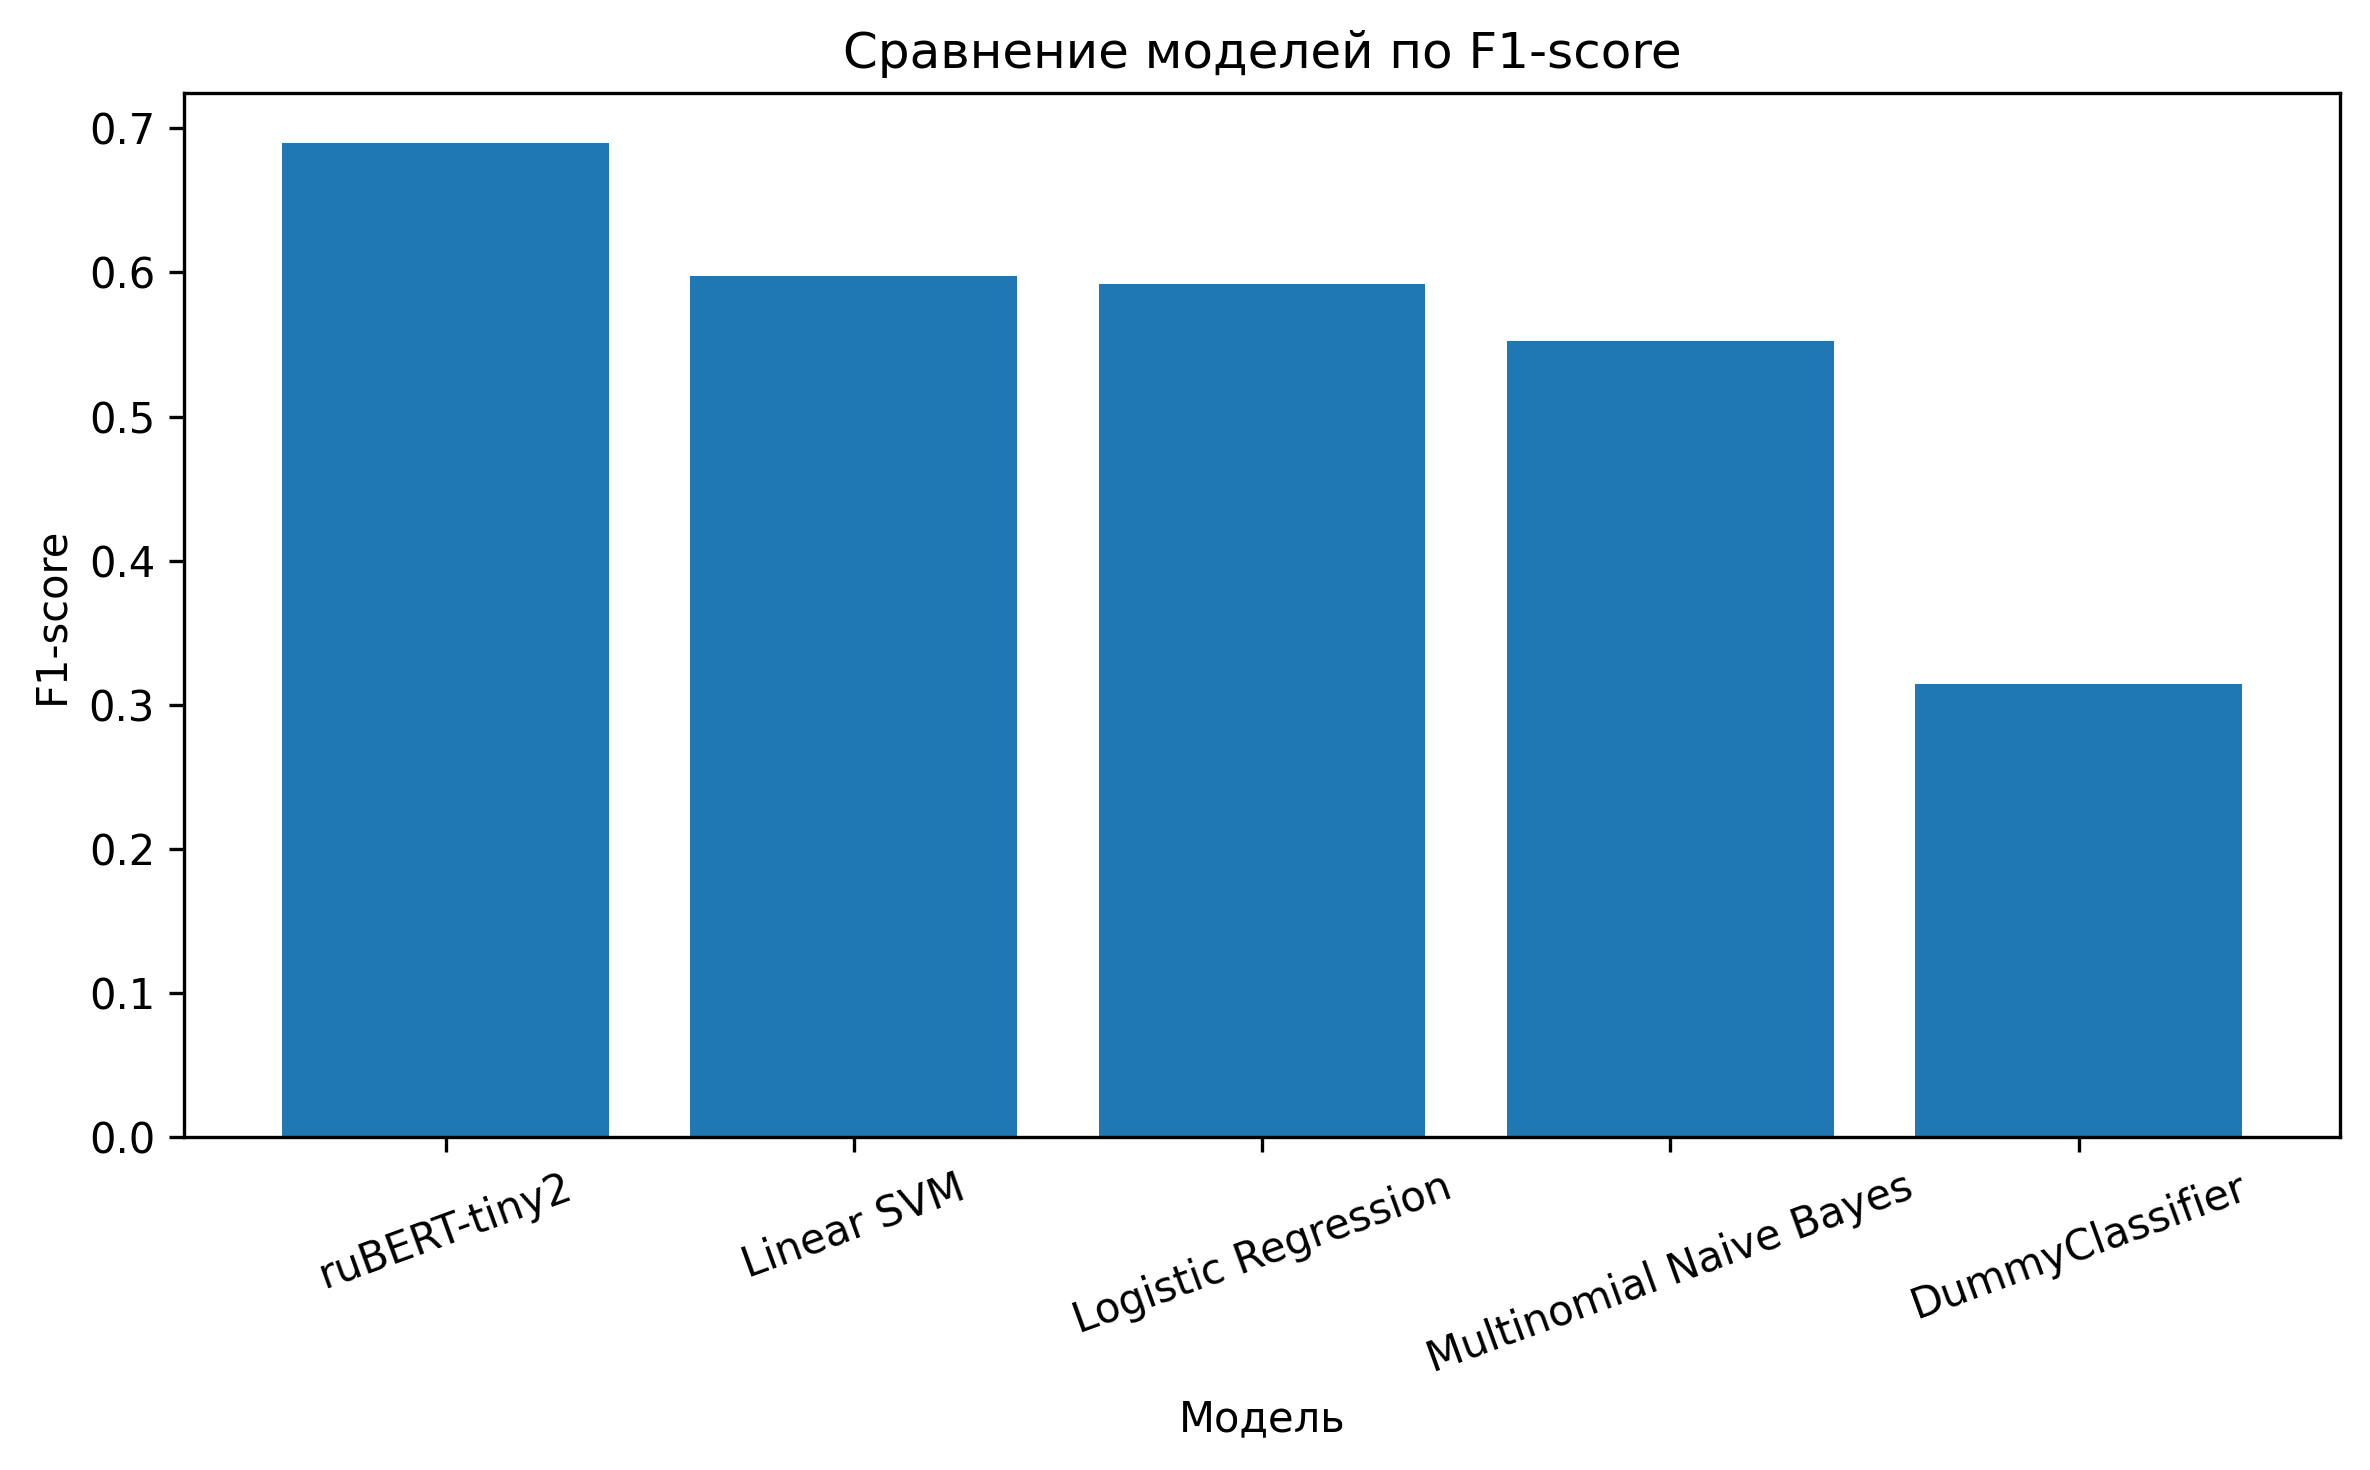

In [43]:
results_plot = results_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(results_plot["Model"], results_plot["F1-score"])
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Сохраняем модель и токенизатор

In [44]:
save_path = "/content/rubert_tiny2_sentiment_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/rubert_tiny2_sentiment_model


Сохраним всю таблицу

In [45]:
results_df.to_csv("all_model_results.csv", index=False)

График сравнения моделей

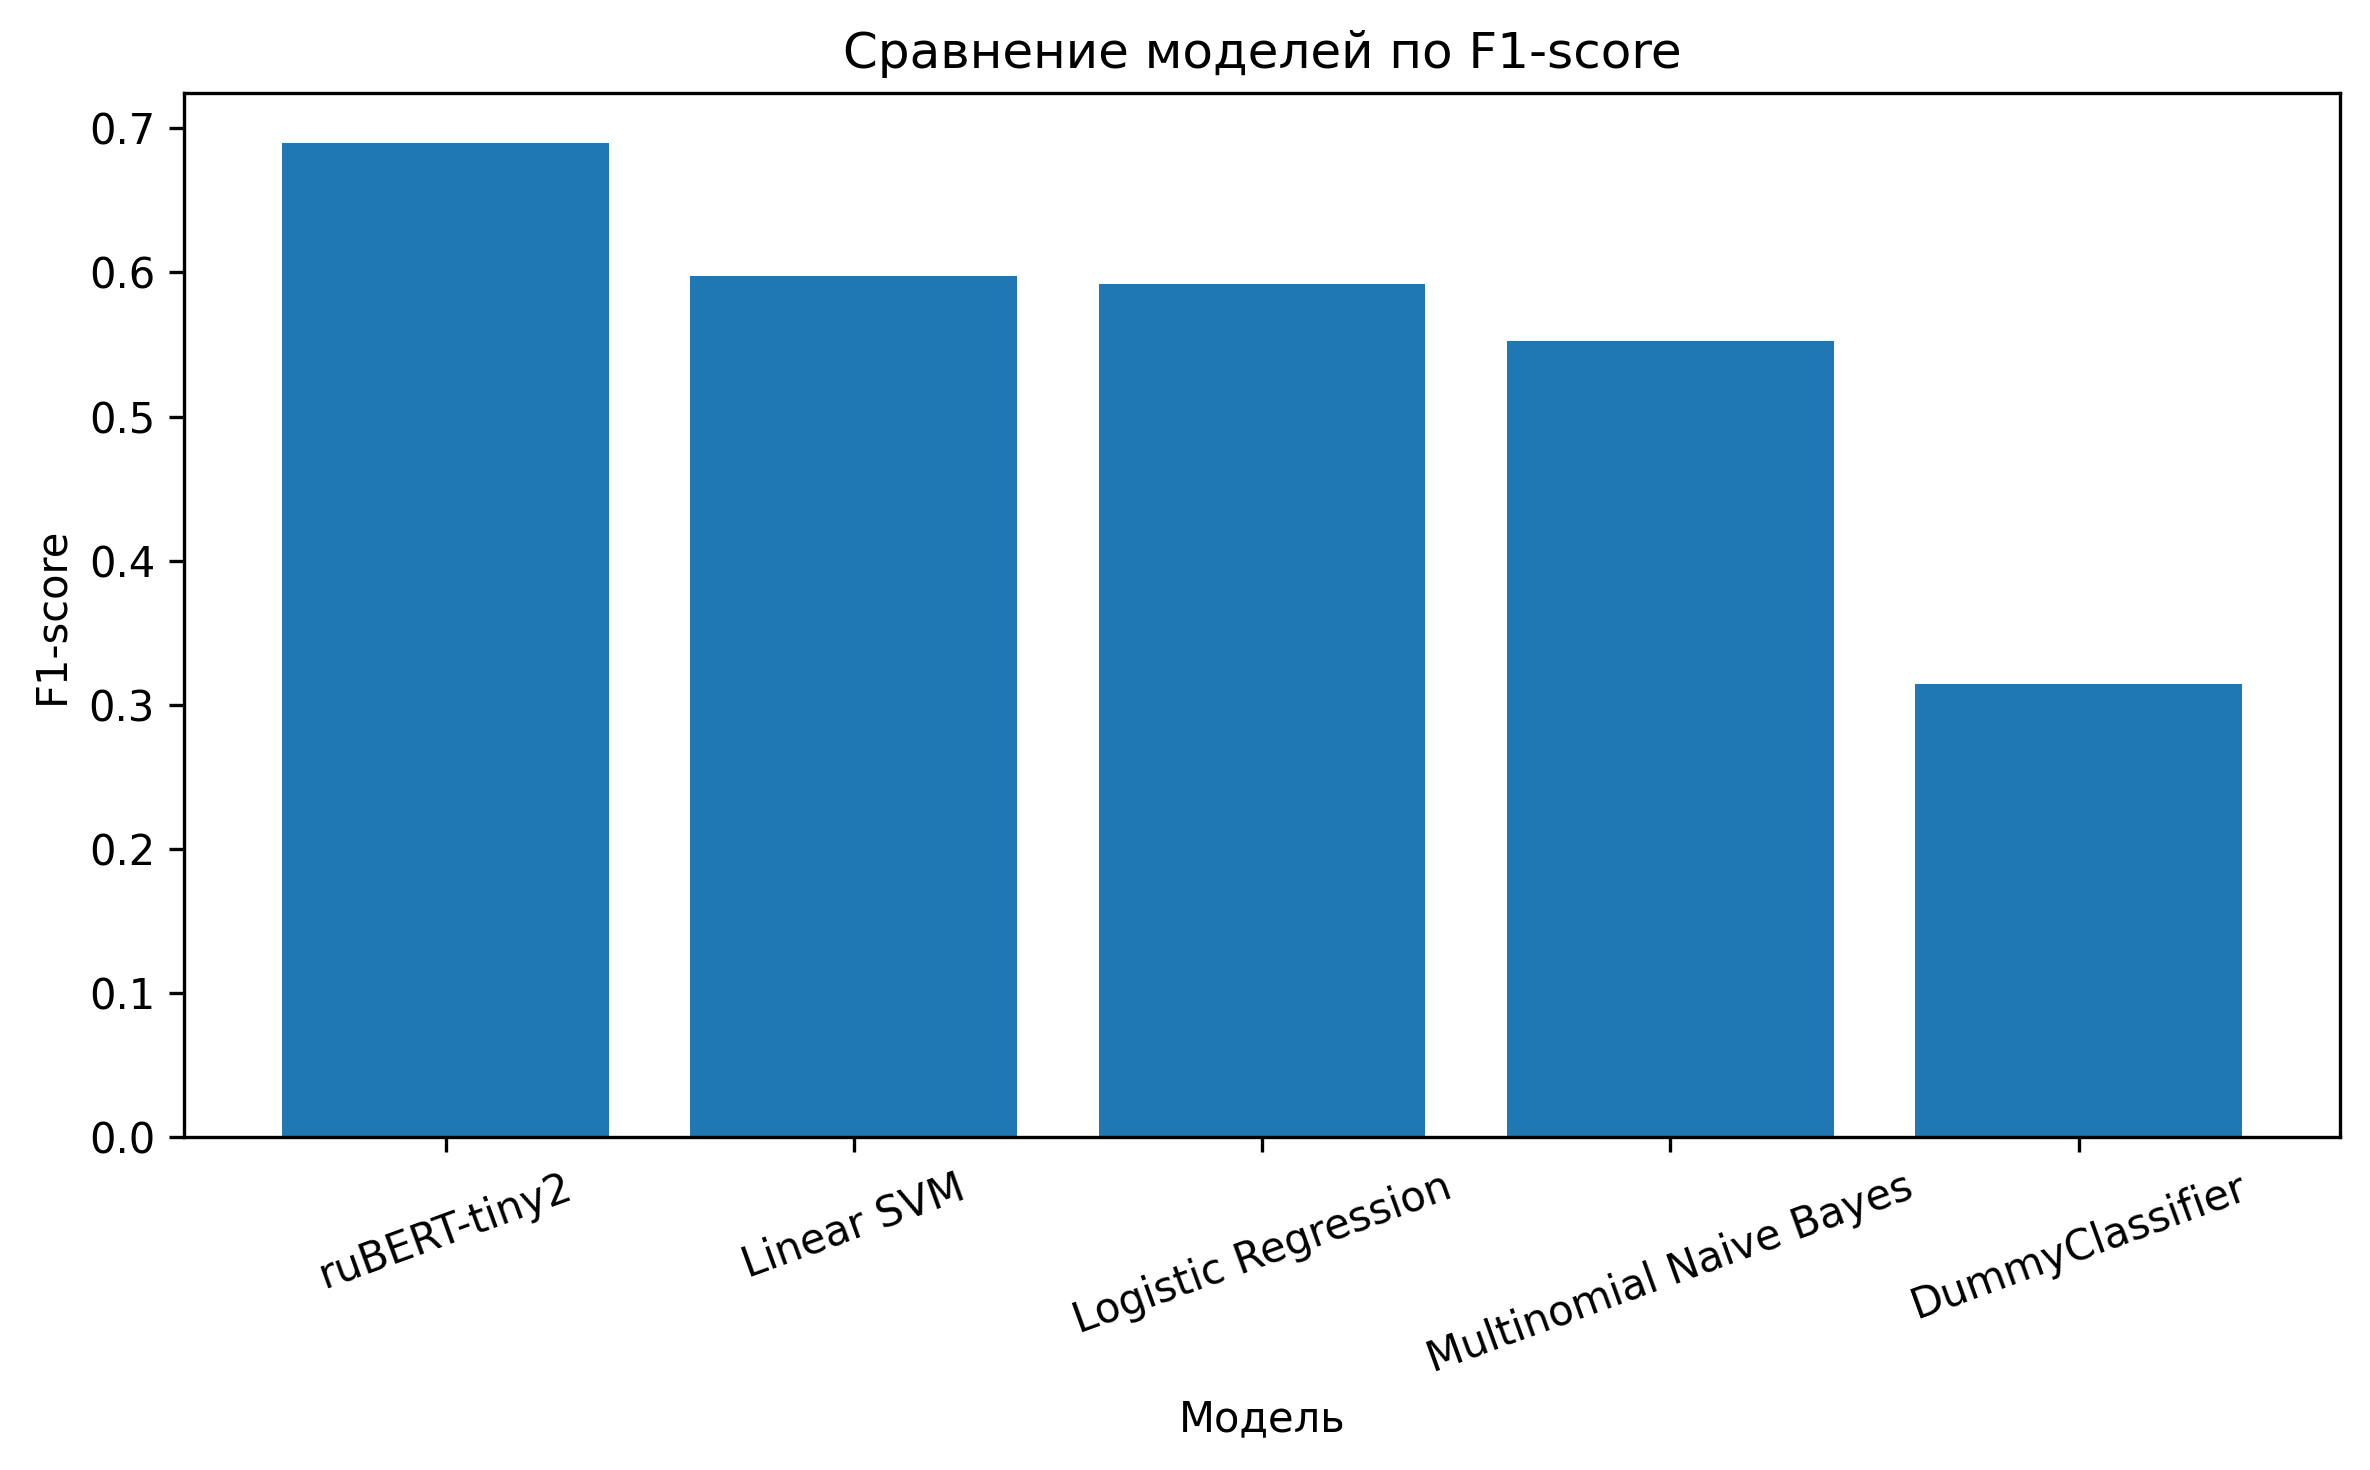

In [47]:
import matplotlib.pyplot as plt

results_plot = results_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(8, 5), dpi=300)
plt.bar(results_plot["Model"], results_plot["F1-score"])
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("models_comparison_f1.png", dpi=300)
plt.show()

Сохраним confusion matrix BERT

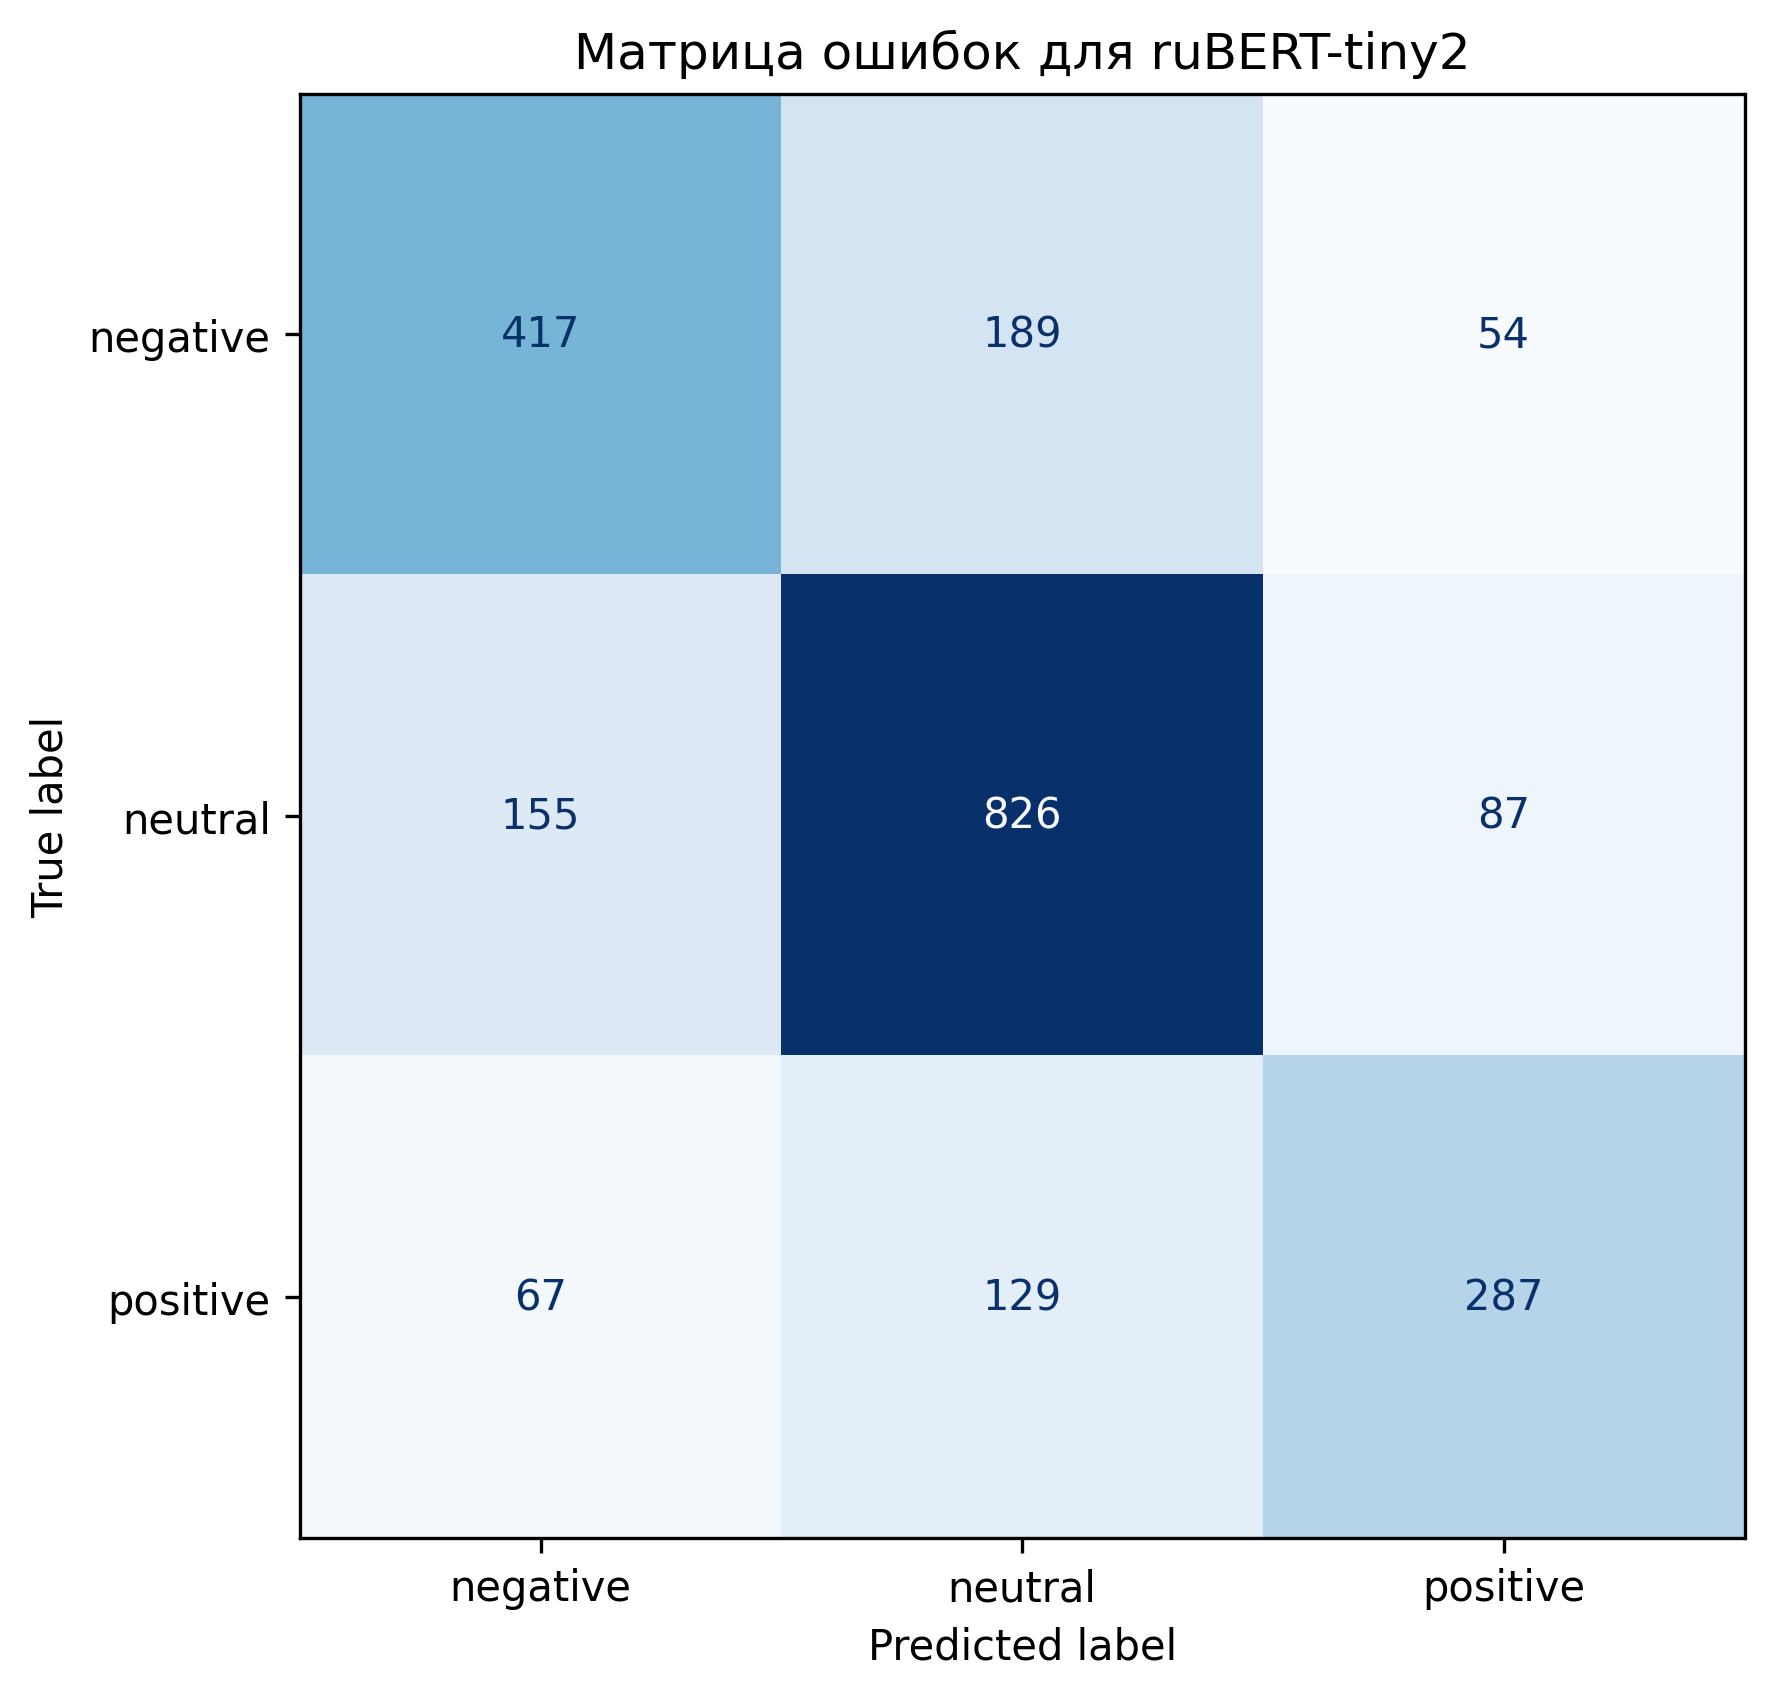

In [49]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для ruBERT-tiny2")
plt.tight_layout()
plt.savefig("confusion_matrix_rubert_tiny2.png", dpi=300)
plt.show()

classification report BERT safe

In [50]:
report_bert = classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_names,
    digits=4
)

with open("classification_report_rubert_tiny2.txt", "w", encoding="utf-8") as f:
    f.write(report_bert)

print(report_bert)

              precision    recall  f1-score   support

    negative     0.6526    0.6318    0.6420       660
     neutral     0.7220    0.7734    0.7468      1068
    positive     0.6706    0.5942    0.6301       483

    accuracy                         0.6920      2211
   macro avg     0.6817    0.6665    0.6730      2211
weighted avg     0.6901    0.6920    0.6900      2211



model+tokenizator safe

In [51]:
save_path = "/content/rubert_tiny2_sentiment_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/rubert_tiny2_sentiment_model


ЭТАП 2

Перетокенизируем данные с длиной 128

In [52]:
def tokenize_function_v2(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized_v2 = train_dataset.map(tokenize_function_v2, batched=True)
test_tokenized_v2 = test_dataset.map(tokenize_function_v2, batched=True)

Map:   0%|          | 0/8842 [00:00<?, ? examples/s]

Map:   0%|          | 0/2211 [00:00<?, ? examples/s]

Подготовим для Trainer

In [53]:
train_tokenized_v2 = train_tokenized_v2.rename_column("label_id", "labels")
test_tokenized_v2 = test_tokenized_v2.rename_column("label_id", "labels")

train_tokenized_v2.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized_v2.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Загрузим модель заново

In [54]:
from transformers import AutoModelForSequenceClassification

model_v2 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

новые аргументы тренировки

In [55]:
from transformers import TrainingArguments

training_args_v2 = TrainingArguments(
    output_dir="./rubert_tiny_results_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    num_train_epochs=3,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True
)

создадим нового Trainer

In [58]:
from transformers import Trainer

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_tokenized_v2,
    eval_dataset=test_tokenized_v2,
    compute_metrics=compute_metrics
)

Запустим новое обучение

In [59]:
trainer_v2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.772314,0.705145,0.691542,0.690168,0.691542,0.690583,0.675840
2,0.655126,0.679304,0.709634,0.708554,0.709634,0.708010,0.693627
3,0.592051,0.676998,0.705111,0.704871,0.705111,0.704914,0.691243


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=1659, training_loss=0.7099028662646514, metrics={'train_runtime': 67.1806, 'train_samples_per_second': 394.846, 'train_steps_per_second': 24.695, 'total_flos': 48908429987328.0, 'train_loss': 0.7099028662646514, 'epoch': 3.0})

In [60]:
eval_results_v2 = trainer_v2.evaluate()
print(eval_results_v2)

{'eval_loss': 0.6792337894439697, 'eval_accuracy': 0.7091813658977838, 'eval_precision_weighted': 0.708148971813353, 'eval_recall_weighted': 0.7091813658977838, 'eval_f1_weighted': 0.7075883369639328, 'eval_f1_macro': 0.6932113870026742, 'eval_runtime': 2.2314, 'eval_samples_per_second': 990.862, 'eval_steps_per_second': 62.293, 'epoch': 3.0}


In [61]:
pred_output_v2 = trainer_v2.predict(test_tokenized_v2)

import numpy as np
y_pred_bert_v2 = np.argmax(pred_output_v2.predictions, axis=-1)
y_true_bert_v2 = pred_output_v2.label_ids

In [62]:
from sklearn.metrics import classification_report

label_names = ["negative", "neutral", "positive"]

report_bert_v2 = classification_report(
    y_true_bert_v2,
    y_pred_bert_v2,
    target_names=label_names,
    digits=4
)

print(report_bert_v2)

              precision    recall  f1-score   support

    negative     0.6969    0.6167    0.6543       660
     neutral     0.7372    0.7828    0.7593      1068
    positive     0.6592    0.6729    0.6660       483

    accuracy                         0.7092      2211
   macro avg     0.6978    0.6908    0.6932      2211
weighted avg     0.7081    0.7092    0.7076      2211



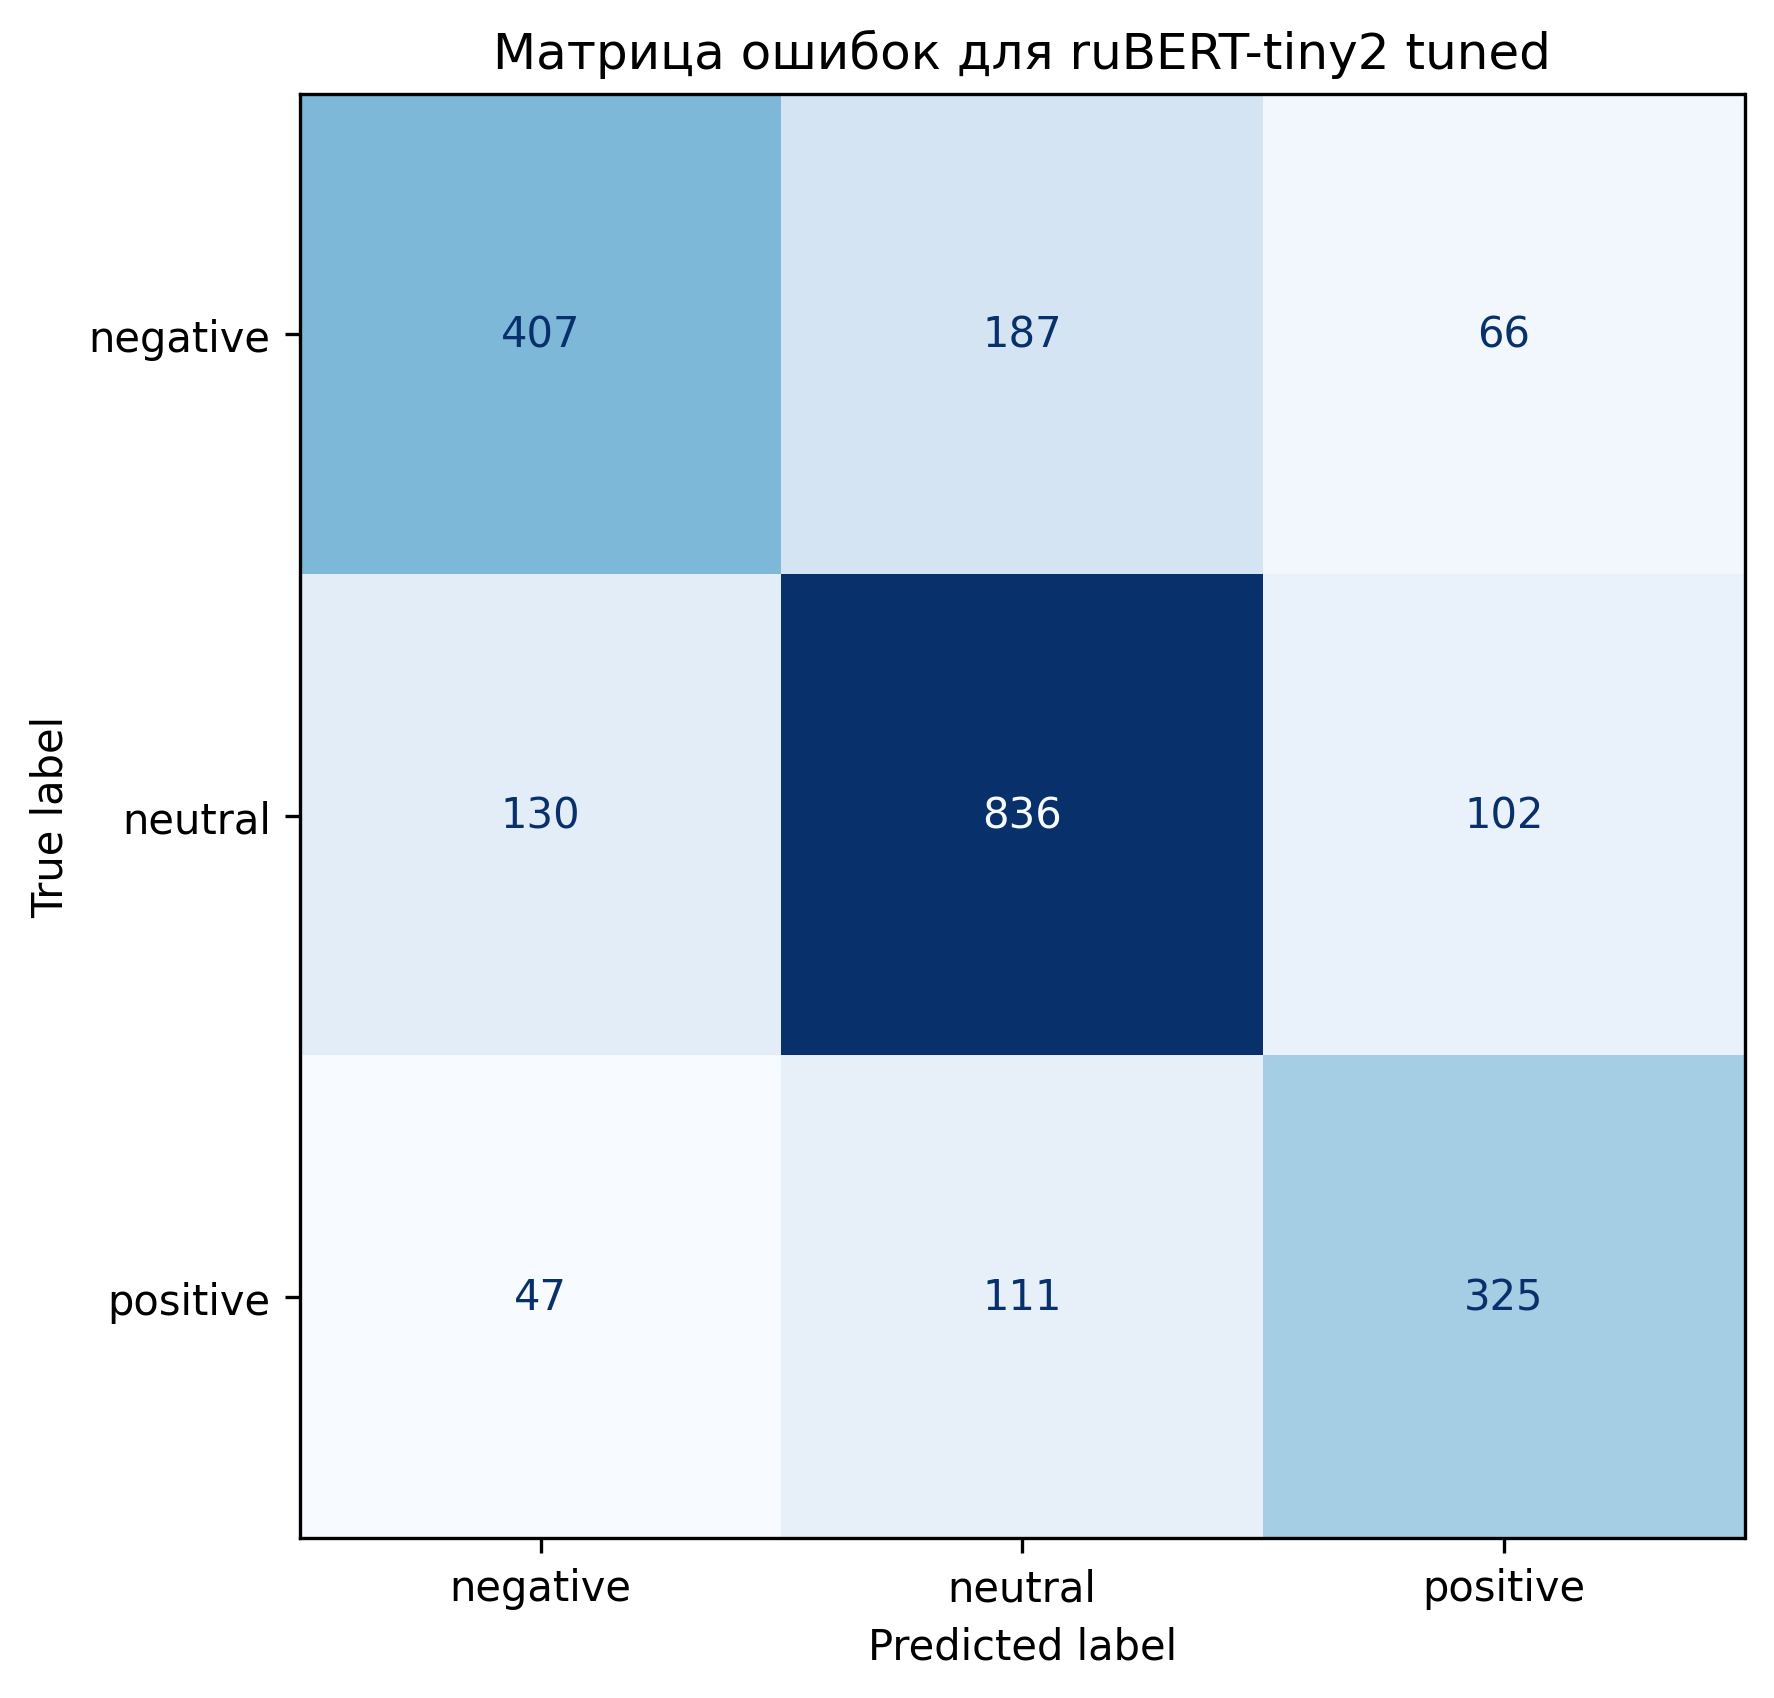

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bert_v2 = confusion_matrix(y_true_bert_v2, y_pred_bert_v2, labels=[0, 1, 2])
disp_bert_v2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert_v2,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert_v2.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для ruBERT-tiny2 tuned")
plt.tight_layout()
plt.show()

In [65]:
bert_v2_result = {
    "Model": "ruBERT-tiny2 tuned",
    "Accuracy": round(eval_results_v2["eval_accuracy"], 4),
    "Precision": round(eval_results_v2["eval_precision_weighted"], 4),
    "Recall": round(eval_results_v2["eval_recall_weighted"], 4),
    "F1-score": round(eval_results_v2["eval_f1_weighted"], 4)
}

results_df = pd.concat([results_df, pd.DataFrame([bert_v2_result])], ignore_index=True)
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,ruBERT-tiny2 tuned,0.7092,0.7081,0.7092,0.7076
1,ruBERT-tiny2,0.6920,0.6901,0.6920,0.6900
2,Linear SVM,0.6061,0.6015,0.6061,0.5975
3,Logistic Regression,0.6106,0.6207,0.6106,0.5921
4,Multinomial Naive Bayes,0.5957,0.6500,0.5957,0.5521
5,DummyClassifier,0.4830,0.2333,0.4830,0.3147


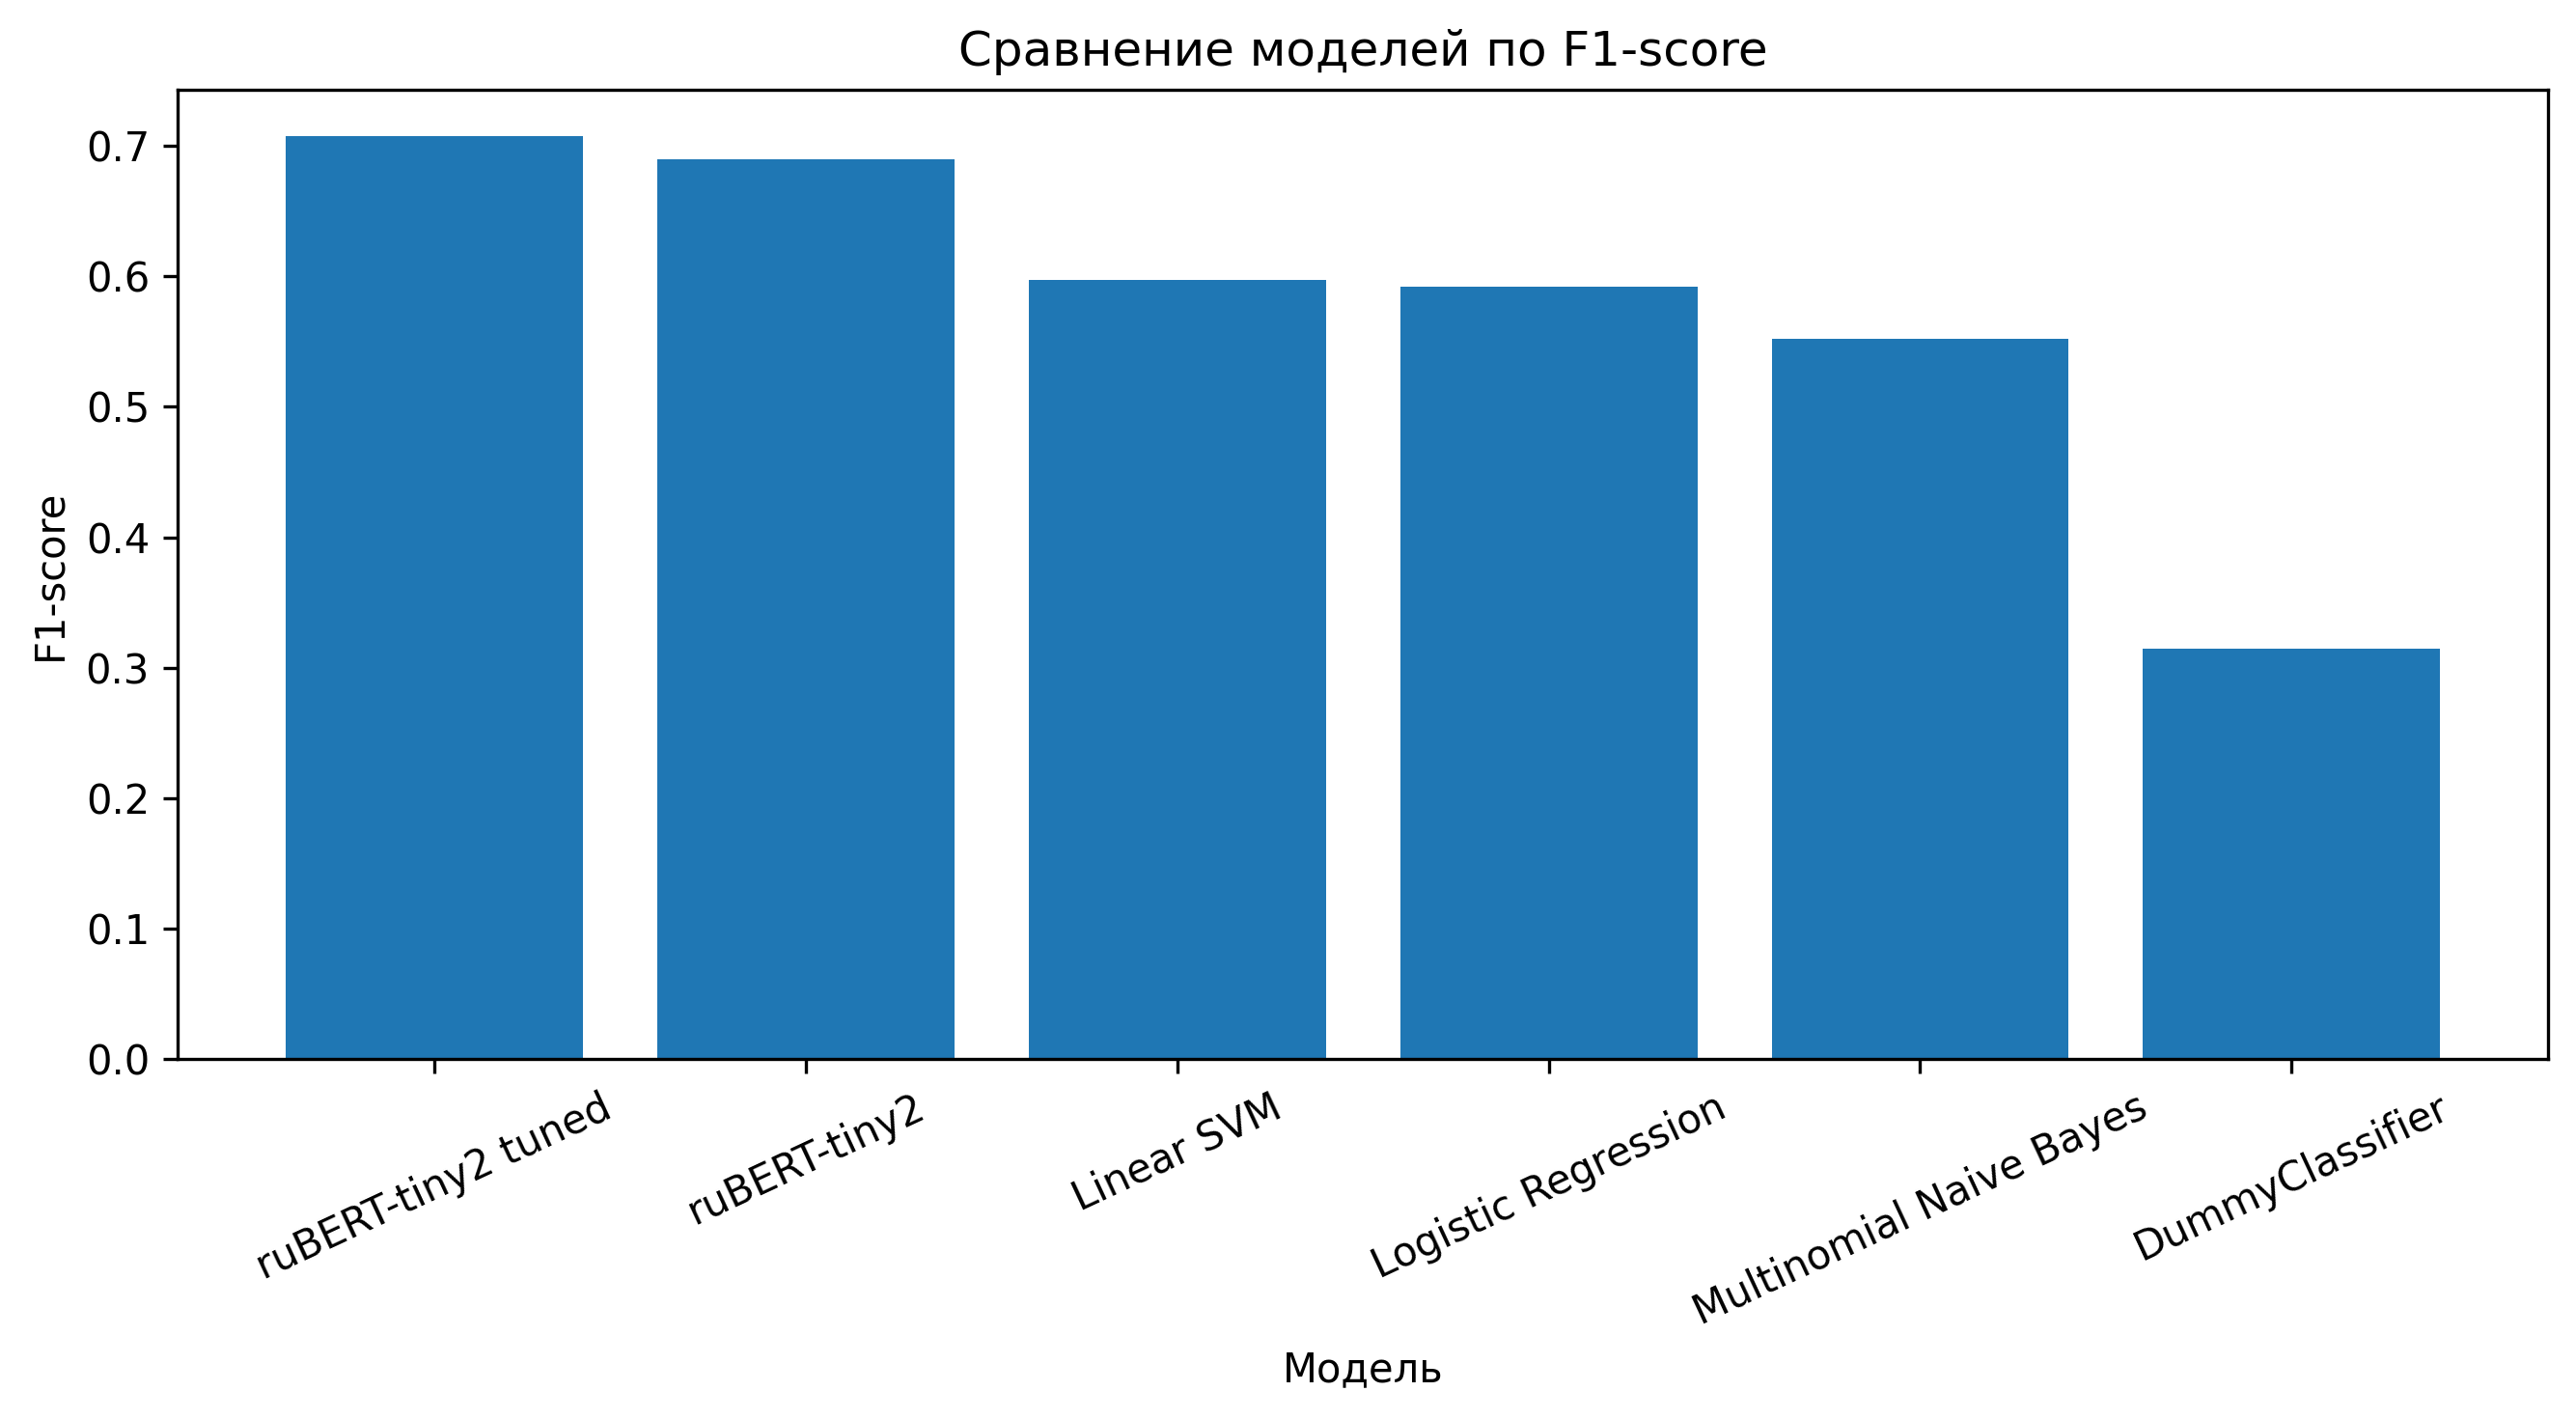

In [68]:
results_plot = results_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(results_plot["Model"], results_plot["F1-score"])
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [67]:
save_path_v2 = "/content/rubert_tiny2_sentiment_model_tuned"

trainer_v2.save_model(save_path_v2)
tokenizer.save_pretrained(save_path_v2)

print("Model saved to:", save_path_v2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/rubert_tiny2_sentiment_model_tuned


In [ ]:
СОХРАНЯЕМ ВСЕ НЕОБХОДИМОЕ ДЛЯ github

Итоговоая таблица

In [69]:
results_df.to_csv("final_results_table.csv", index=False)

График сравнения моделей

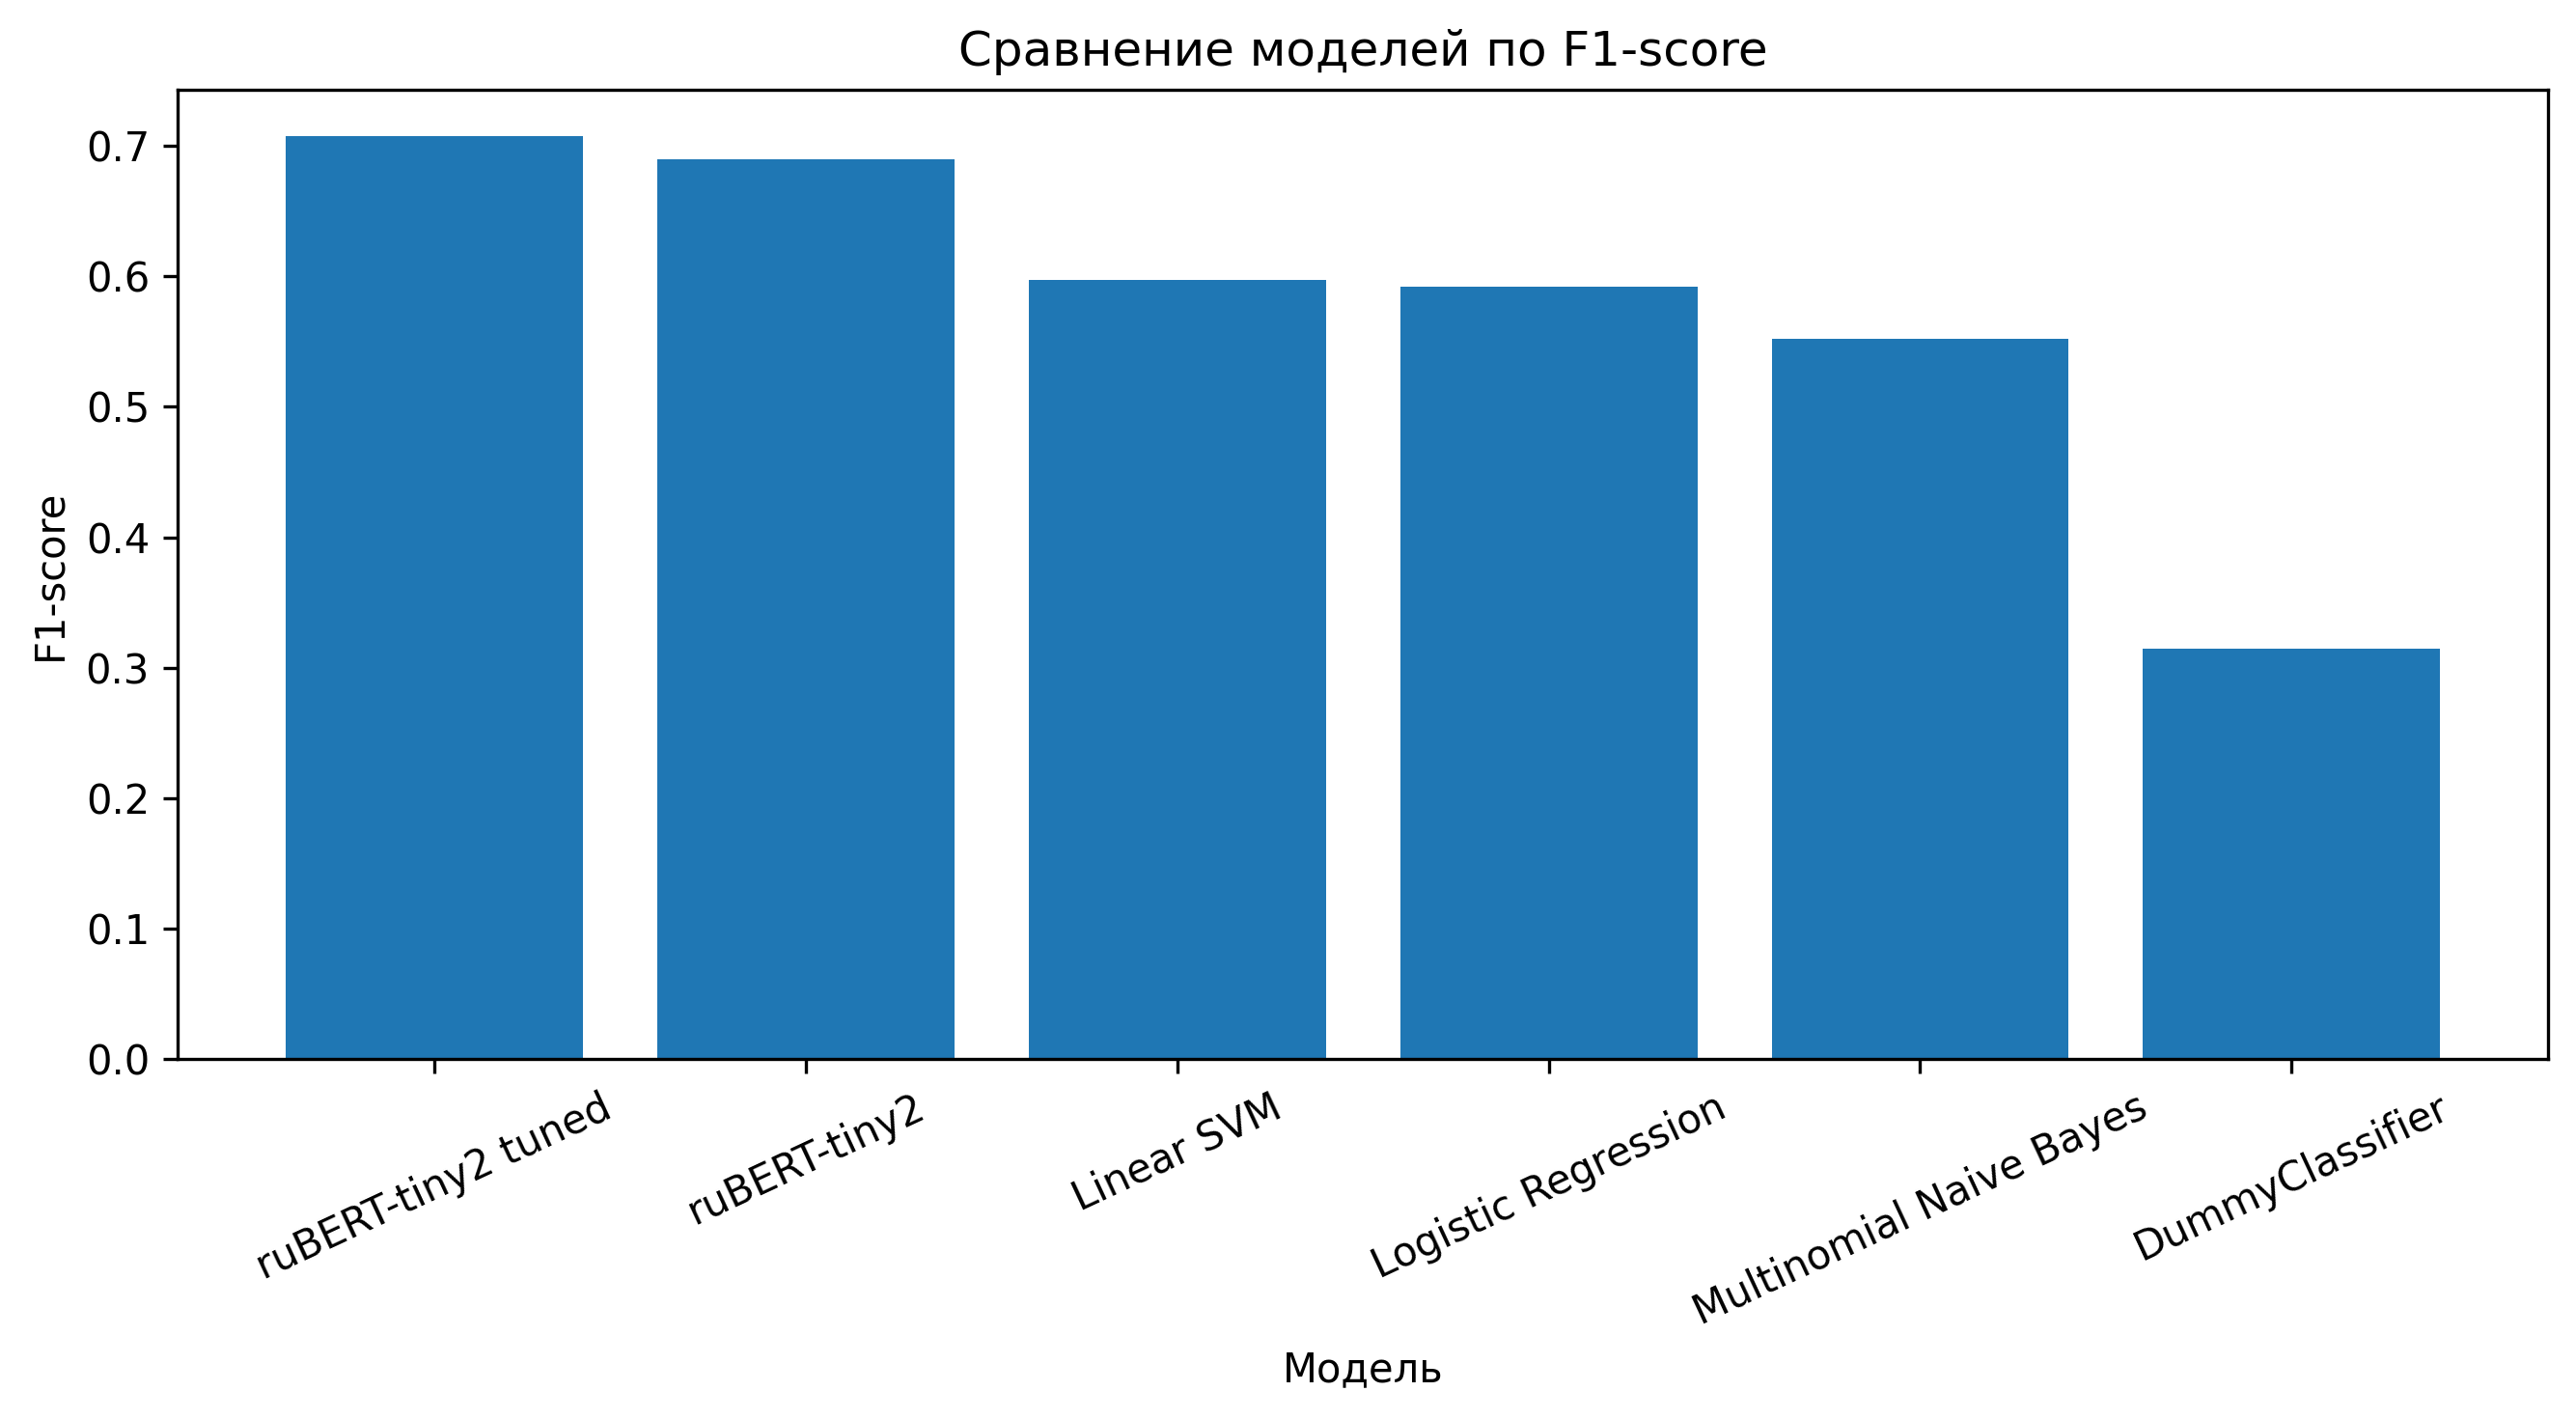

In [71]:
import matplotlib.pyplot as plt

results_plot = results_df.sort_values(by="F1-score", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(results_plot["Model"], results_plot["F1-score"])
plt.title("Сравнение моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("final_models_comparison_f1.png", dpi=300)
plt.show()

confusion matrix bert-tuned

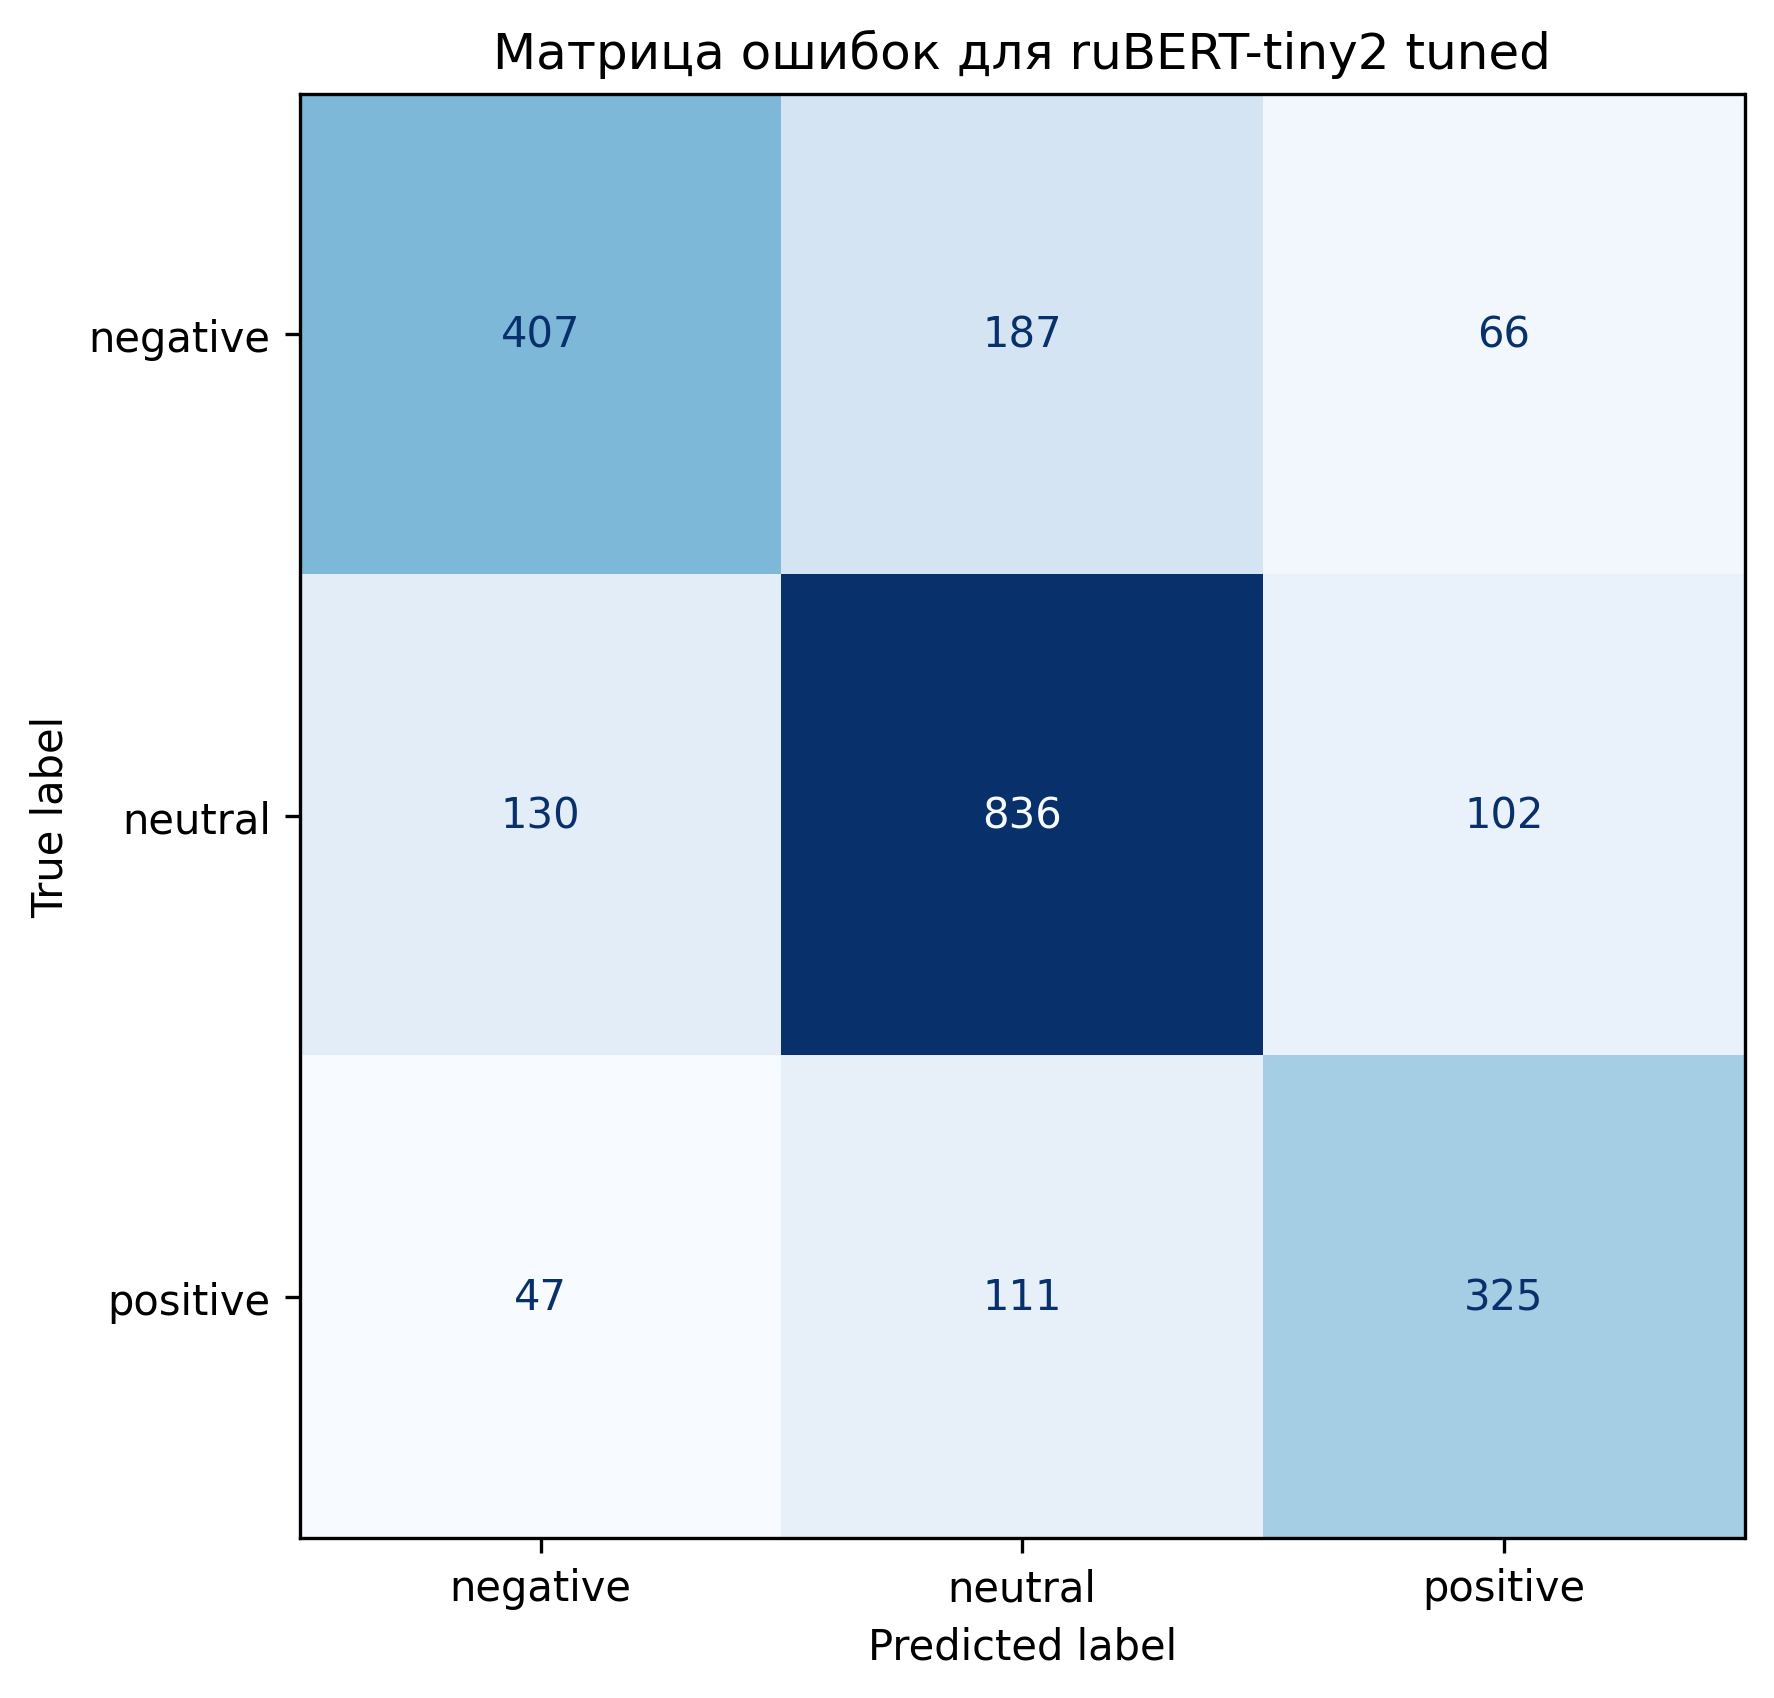

In [72]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_bert_v2.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Матрица ошибок для ruBERT-tiny2 tuned")
plt.tight_layout()
plt.savefig("confusion_matrix_rubert_tiny2_tuned.png", dpi=300)
plt.show()

In [73]:
save_path_v2 = "/content/rubert_tiny2_sentiment_model_tuned"
trainer_v2.save_model(save_path_v2)
tokenizer.save_pretrained(save_path_v2)
print("Model saved to:", save_path_v2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/rubert_tiny2_sentiment_model_tuned
